In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv("Clean_Dataset.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [2]:
print("First 5 rows:")
print(df.head())
print("\n" + "="*80 + "\n")


print(f"Dataset Shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\n" + "="*80 + "\n")


print("Column Names:")
print(df.columns.tolist())
print("\n" + "="*80 + "\n")


print("Data Types:")
print(df.dtypes)
print("\n" + "="*80 + "\n")


print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

First 5 rows:
   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  


Dataset Shape: (300153, 12)
Number of rows: 300153
Number of columns: 12


Column Names:
['Unnamed: 0', 'airline', 'flight', 'sourc

In [3]:
#Categorical features
categorical = df.select_dtypes(include=['object']).columns.tolist()

# Numerical features  
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Display results
categorical
numerical

# Summary
pd.DataFrame({
    'Feature Type': ['Categorical', 'Numerical', 'Total'],
    'Count': [len(categorical), len(numerical), len(df.columns)]
})

,Feature Type,Count
0,Categorical,8
1,Numerical,4
2,Total,12


In [4]:
print("FEATURE CLASSIFICATION")
print("=" * 60)
print("\n")

# Find categorical features (text columns)
categorical = df.select_dtypes(include=['object']).columns.tolist()

# Find numerical features (number columns)
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Show categorical features
print("QUALITATIVE (CATEGORICAL) FEATURES:")
print("-" * 60)
for feature in categorical:
    print(f"• {feature}")
print(f"\nTotal: {len(categorical)} features\n")

# Show numerical features
print("QUANTITATIVE (NUMERICAL) FEATURES:")
print("-" * 60)
for feature in numerical:
    print(f"• {feature}")
print(f"\nTotal: {len(numerical)} features\n")

# Summary
print("=" * 60)
print(f"TOTAL FEATURES: {len(df.columns)}")
print(f"  - Categorical: {len(categorical)}")
print(f"  - Numerical: {len(numerical)}")
print("=" * 60)

FEATURE CLASSIFICATION


QUALITATIVE (CATEGORICAL) FEATURES:
------------------------------------------------------------
• airline
• flight
• source_city
• departure_time
• stops
• arrival_time
• destination_city
• class

Total: 8 features

QUANTITATIVE (NUMERICAL) FEATURES:
------------------------------------------------------------
• Unnamed: 0
• duration
• days_left
• price

Total: 4 features

TOTAL FEATURES: 12
  - Categorical: 8
  - Numerical: 4


In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv("Clean_Dataset.CSV")

# Create classification dictionary
classification = {
    'Feature': [],
    'Level of Measurement': [],
    'Justification': []
}

# Get all column names
columns = df.columns.tolist()

# Classification based on YOUR actual dataset
for col in columns:
    classification['Feature'].append(col)
    
    # Nominal - Categories with no order
    if col in ['airline', 'flight', 'source_city', 'destination_city', 'class']:
        classification['Level of Measurement'].append('Nominal')
        classification['Justification'].append('Categories with no inherent order or ranking')
    
    # Ordinal - Categories with meaningful order
    elif col in ['stops', 'departure_time', 'arrival_time']:
        classification['Level of Measurement'].append('Ordinal')
        classification['Justification'].append('Has natural order but differences between values are not equal')
    
    # Interval - Numeric with no true zero
    elif col in ['days_left']:
        classification['Level of Measurement'].append('Interval')
        classification['Justification'].append('Has order and equal intervals, but no true zero point')
    
    # Ratio - Numeric with true zero
    elif col in ['duration', 'price']:
        classification['Level of Measurement'].append('Ratio')
        classification['Justification'].append('Has order, equal intervals, and true zero (zero means absence)')
    
    # Default check based on data type
    else:
        if df[col].dtype == 'object':
            classification['Level of Measurement'].append('Nominal')
            classification['Justification'].append('Categorical data with no inherent order')
        else:
            classification['Level of Measurement'].append('Ratio')
            classification['Justification'].append('Numerical data with true zero point')

# Create DataFrame
result_df = pd.DataFrame(classification)

# Display the table
result_df

,Feature,Level of Measurement,Justification
0,Unnamed: 0,Ratio,Numerical data with true zero point
1,airline,Nominal,Categories with no inherent order or ranking
2,flight,Nominal,Categories with no inherent order or ranking
3,source_city,Nominal,Categories with no inherent order or ranking
4,departure_time,Ordinal,Has natural order but differences between valu...
5,stops,Ordinal,Has natural order but differences between valu...
6,arrival_time,Ordinal,Has natural order but differences between valu...
7,destination_city,Nominal,Categories with no inherent order or ranking
8,class,Nominal,Categories with no inherent order or ranking
9,duration,Ratio,"Has order, equal intervals, and true zero (zer..."


# COMPREHENSIVE FLIGHT PRICE PREDICTION - EXPLORATORY DATA ANALYSIS
## Complete Analysis of All Features and Their Impact on Flight Prices

In [42]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load dataset
df = pd.read_csv('Clean_Dataset.CSV')

print('='*80)
print('FLIGHT PRICE PREDICTION - COMPREHENSIVE EDA')
print('='*80)
print(f'Dataset Shape: {df.shape}')
print(f'Total Records: {len(df):,}')
print(f'Total Features: {len(df.columns)}')
print('='*80)

FLIGHT PRICE PREDICTION - COMPREHENSIVE EDA
Dataset Shape: (300153, 12)
Total Records: 300,153
Total Features: 12


---
## 1. TARGET VARIABLE ANALYSIS (PRICE)
### Understanding the distribution and characteristics of flight prices

In [43]:
# 1. TARGET VARIABLE ANALYSIS
print('\n' + '='*80)
print('1. TARGET VARIABLE ANALYSIS - FLIGHT PRICE')
print('='*80 + '\n')

# Calculate statistics
price_mean = df['price'].mean()
price_median = df['price'].median()
price_min = df['price'].min()
price_max = df['price'].max()
price_std = df['price'].std()
price_var = df['price'].var()
price_skew = df['price'].skew()
price_kurt = df['price'].kurtosis()

print('PRICE STATISTICS:')
print('-'*80)
print(f'Mean Price:       ₹{price_mean:,.2f}')
print(f'Median Price:     ₹{price_median:,.2f}')
print(f'Minimum Price:    ₹{price_min:,.2f}')
print(f'Maximum Price:    ₹{price_max:,.2f}')
print(f'Price Range:      ₹{price_max - price_min:,.2f}')
print(f'\nStandard Dev:     ₹{price_std:,.2f}')
print(f'Variance:         ₹{price_var:,.2f}')
print(f'\nSkewness:         {price_skew:.4f}')
print(f'Kurtosis:         {price_kurt:.4f}')

# Quartiles
print(f'\nQUARTILES:')
print(f'Q1 (25%):         ₹{df["price"].quantile(0.25):,.2f}')
print(f'Q2 (50%):         ₹{df["price"].quantile(0.50):,.2f}')
print(f'Q3 (75%):         ₹{df["price"].quantile(0.75):,.2f}')
print(f'IQR:              ₹{df["price"].quantile(0.75) - df["price"].quantile(0.25):,.2f}')


1. TARGET VARIABLE ANALYSIS - FLIGHT PRICE

PRICE STATISTICS:
--------------------------------------------------------------------------------
Mean Price:       ₹20,889.66
Median Price:     ₹7,425.00
Minimum Price:    ₹1,105.00
Maximum Price:    ₹123,071.00
Price Range:      ₹121,966.00

Standard Dev:     ₹22,697.77
Variance:         ₹515,188,643.40

Skewness:         1.0614
Kurtosis:         -0.3963

QUARTILES:
Q1 (25%):         ₹4,783.00
Q2 (50%):         ₹7,425.00
Q3 (75%):         ₹42,521.00
IQR:              ₹37,738.00


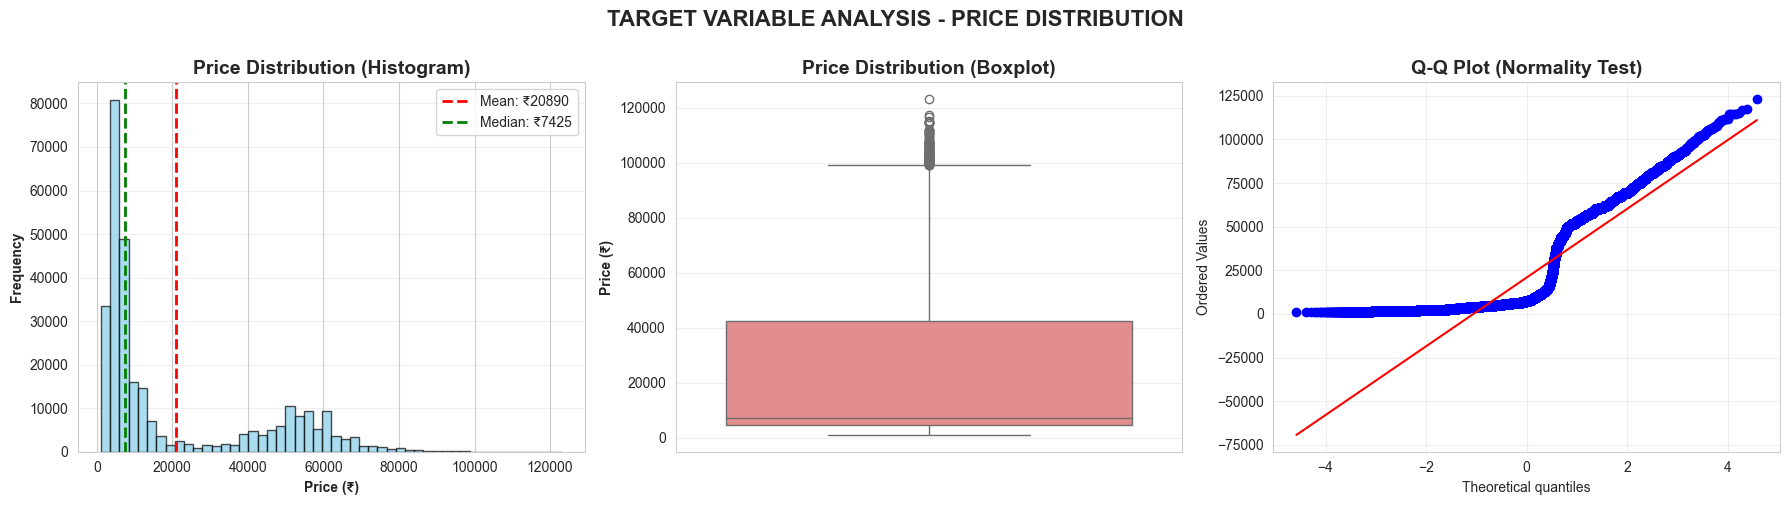


INTERPRETATION:
--------------------------------------------------------------------------------
✓ Positive skewness (1.06): Prices are right-skewed
  → Most flights are cheaper, few expensive flights pull mean up
  → Mean > Median indicates outliers on the high end


In [44]:
# Visualization - Price Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['price'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(price_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: ₹{price_mean:.0f}')
axes[0].axvline(price_median, color='green', linestyle='--', linewidth=2, label=f'Median: ₹{price_median:.0f}')
axes[0].set_xlabel('Price (₹)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Price Distribution (Histogram)', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box Plot
sns.boxplot(y=df['price'], ax=axes[1], color='lightcoral')
axes[1].set_ylabel('Price (₹)', fontweight='bold')
axes[1].set_title('Price Distribution (Boxplot)', fontweight='bold', fontsize=14)
axes[1].grid(axis='y', alpha=0.3)

# Q-Q Plot
stats.probplot(df['price'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Test)', fontweight='bold', fontsize=14)
axes[2].grid(alpha=0.3)

plt.suptitle('TARGET VARIABLE ANALYSIS - PRICE DISTRIBUTION', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Interpretation
print('\nINTERPRETATION:')
print('-'*80)
if price_skew > 0.5:
    print(f'✓ Positive skewness ({price_skew:.2f}): Prices are right-skewed')
    print('  → Most flights are cheaper, few expensive flights pull mean up')
    print('  → Mean > Median indicates outliers on the high end')
elif price_skew < -0.5:
    print(f'✓ Negative skewness ({price_skew:.2f}): Prices are left-skewed')
else:
    print(f'✓ Low skewness ({price_skew:.2f}): Prices are fairly symmetric')

---
## 2. AIRLINE ANALYSIS
### Comparing pricing strategies across different airlines

In [45]:
# 2. AIRLINE ANALYSIS
print('\n' + '='*80)
print('2. AIRLINE ANALYSIS')
print('='*80 + '\n')

# Calculate statistics by airline
airline_stats = df.groupby('airline')['price'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Range', lambda x: x.max() - x.min())
]).sort_values('Mean',  ascending=False)

print('AIRLINE PRICE STATISTICS:')
print('-'*80)
print(airline_stats.round(2))

# Identify premium vs budget airlines
overall_mean = df['price'].mean()
premium_airlines = airline_stats[airline_stats['Mean'] > overall_mean]
budget_airlines = airline_stats[airline_stats['Mean'] <= overall_mean]

print(f'\n\nPREMIUM AIRLINES (Above average ₹{overall_mean:.0f}):')
print('-'*80)
for airline in premium_airlines.index:
    avg_price = premium_airlines.loc[airline, 'Mean']
    print(f'  {airline:20} → ₹{avg_price:,.0f}')

print(f'\nBUDGET AIRLINES (Below average ₹{overall_mean:.0f}):')
print('-'*80)
for airline in budget_airlines.index:
    avg_price = budget_airlines.loc[airline, 'Mean']
    print(f'  {airline:20} → ₹{avg_price:,.0f}')


2. AIRLINE ANALYSIS

AIRLINE PRICE STATISTICS:
--------------------------------------------------------------------------------
            Count      Mean   Median   Std Dev   Min     Max   Range
airline                                                             
Vistara    127859  30396.54  15543.0  25637.16  1714  123071  121357
Air_India   80892  23507.02  11520.0  20905.12  1526   90970   89444
SpiceJet     9011   6179.28   5654.0   2999.63  1106   34158   33052
GO_FIRST    23173   5652.01   5336.0   2513.87  1105   32803   31698
Indigo      43120   5324.22   4453.0   3268.89  1105   31952   30847
AirAsia     16098   4091.07   3276.0   2824.06  1105   31917   30812


PREMIUM AIRLINES (Above average ₹20890):
--------------------------------------------------------------------------------
  Vistara              → ₹30,397
  Air_India            → ₹23,507

BUDGET AIRLINES (Below average ₹20890):
--------------------------------------------------------------------------------
  Spice

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29216\1664265828.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sorted, y='airline', x='price', ax=axes[1], palette='Set2')


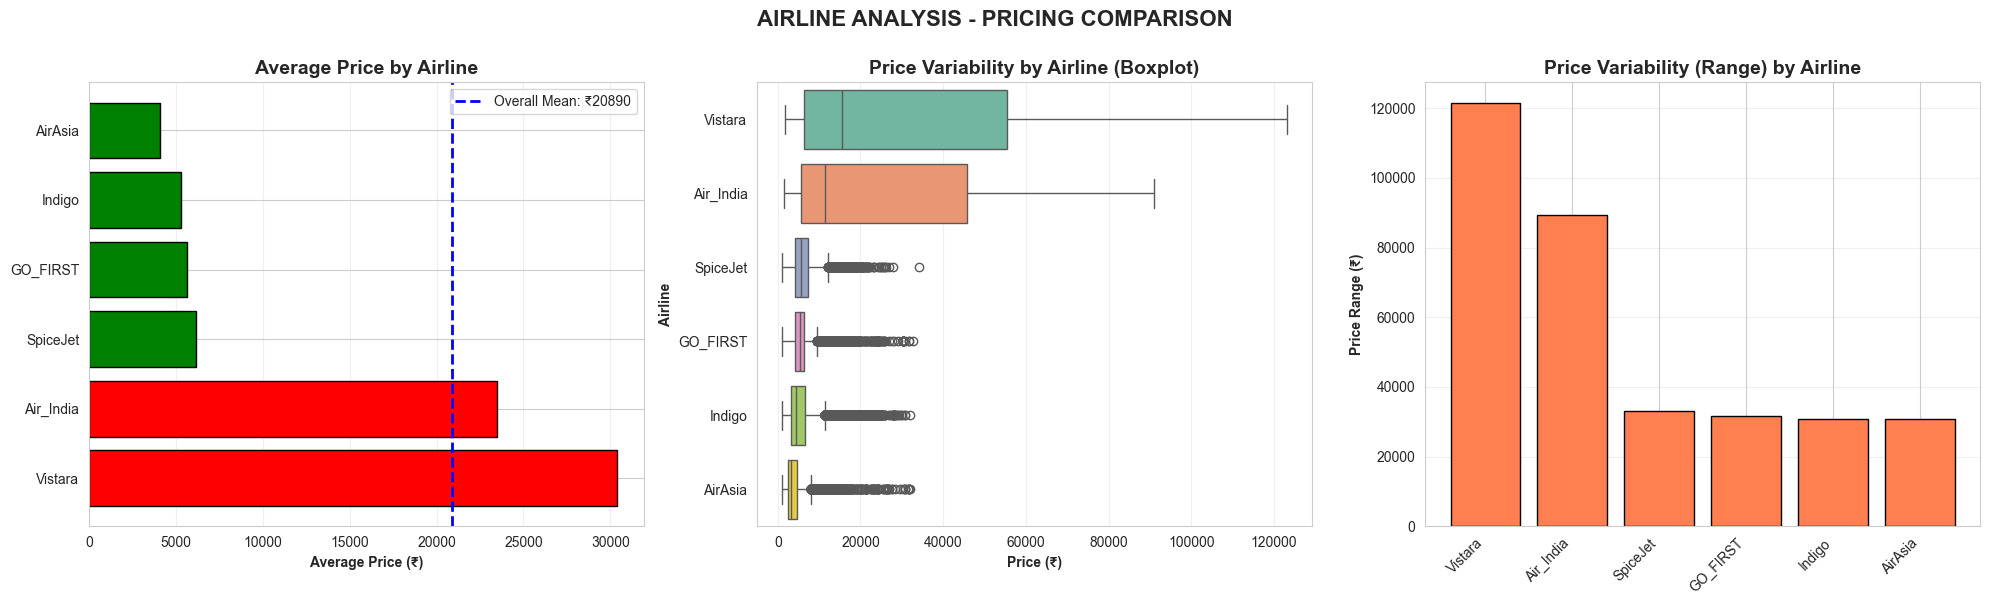

In [46]:
# Visualization - Airline Analysis
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Average price by airline
airline_mean = df.groupby('airline')['price'].mean().sort_values(ascending=False)
colors = ['red' if x > overall_mean else 'green' for x in airline_mean.values]
axes[0].barh(airline_mean.index, airline_mean.values, color=colors, edgecolor='black')
axes[0].axvline(overall_mean, color='blue', linestyle='--', linewidth=2, label=f'Overall Mean: ₹{overall_mean:.0f}')
axes[0].set_xlabel('Average Price (₹)', fontweight='bold')
axes[0].set_title('Average Price by Airline', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Price distribution by airline - Boxplot
df_sorted = df.copy()
df_sorted['airline'] = pd.Categorical(df_sorted['airline'], categories=airline_mean.index, ordered=True)
sns.boxplot(data=df_sorted, y='airline', x='price', ax=axes[1], palette='Set2')
axes[1].set_xlabel('Price (₹)', fontweight='bold')
axes[1].set_ylabel('Airline', fontweight='bold')
axes[1].set_title('Price Variability by Airline (Boxplot)', fontweight='bold', fontsize=14)
axes[1].grid(axis='x', alpha=0.3)

# Price range by airline
airline_range = airline_stats['Range'].sort_values(ascending=False)
axes[2].bar(range(len(airline_range)), airline_range.values, color='coral', edgecolor='black')
axes[2].set_xticks(range(len(airline_range)))
axes[2].set_xticklabels(airline_range.index, rotation=45, ha='right')
axes[2].set_ylabel('Price Range (₹)', fontweight='bold')
axes[2].set_title('Price Variability (Range) by Airline', fontweight='bold', fontsize=14)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('AIRLINE ANALYSIS - PRICING COMPARISON', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

---
## 3. ROUTE ANALYSIS (Source → Destination)
### Analyzing pricing patterns across different routes

In [47]:
# 3. ROUTE ANALYSIS
print('\n' + '='*80)
print('3. ROUTE ANALYSIS (SOURCE → DESTINATION)')
print('='*80 + '\n')

# Source City Analysis
source_stats = df.groupby('source_city')['price'].agg(['mean', 'median', 'min', 'max', 'count']).sort_values('mean', ascending=False)
print('PRICE BY SOURCE CITY:')
print('-'*80)
print(source_stats.round(2))

# Destination City Analysis
dest_stats = df.groupby('destination_city')['price'].agg(['mean', 'median', 'min', 'max', 'count']).sort_values('mean', ascending=False)
print('\nPRICE BY DESTINATION CITY:')
print('-'*80)
print(dest_stats.round(2))

# Route combination analysis
df['route'] = df['source_city'] + ' → ' + df['destination_city']
route_stats = df.groupby('route')['price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

print('\nMOST EXPENSIVE ROUTES (Top 10):')
print('-'*80)
print(route_stats.head(10).round(2))

print('\nCHEAPEST ROUTES (Top 10):')
print('-'*80)
print(route_stats.tail(10).round(2))


3. ROUTE ANALYSIS (SOURCE → DESTINATION)

PRICE BY SOURCE CITY:
--------------------------------------------------------------------------------
                 mean  median   min     max  count
source_city                                       
Chennai      21995.34  7846.0  1105  114704  38700
Kolkata      21746.24  7958.0  2436  123071  46347
Mumbai       21483.82  7413.0  1890  114523  60896
Bangalore    21469.46  7488.0  1603  111883  52061
Hyderabad    20155.62  6855.0  1543  115211  40806
Delhi        18951.33  6840.0  1998  117307  61343

PRICE BY DESTINATION CITY:
--------------------------------------------------------------------------------
                      mean  median   min     max  count
destination_city                                       
Kolkata           21959.56  7767.0  2056  117307  49534
Chennai           21953.32  7900.0  1543  111964  40368
Bangalore         21593.96  7425.0  1443  114523  51068
Mumbai            21372.53  7496.0  1830  115211  59097
H

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29216\772972810.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='source_city', y='price', ax=axes[1, 0], palette='Set3')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29216\772972810.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='destination_city', y='price', ax=axes[1, 1], palette='Set2')


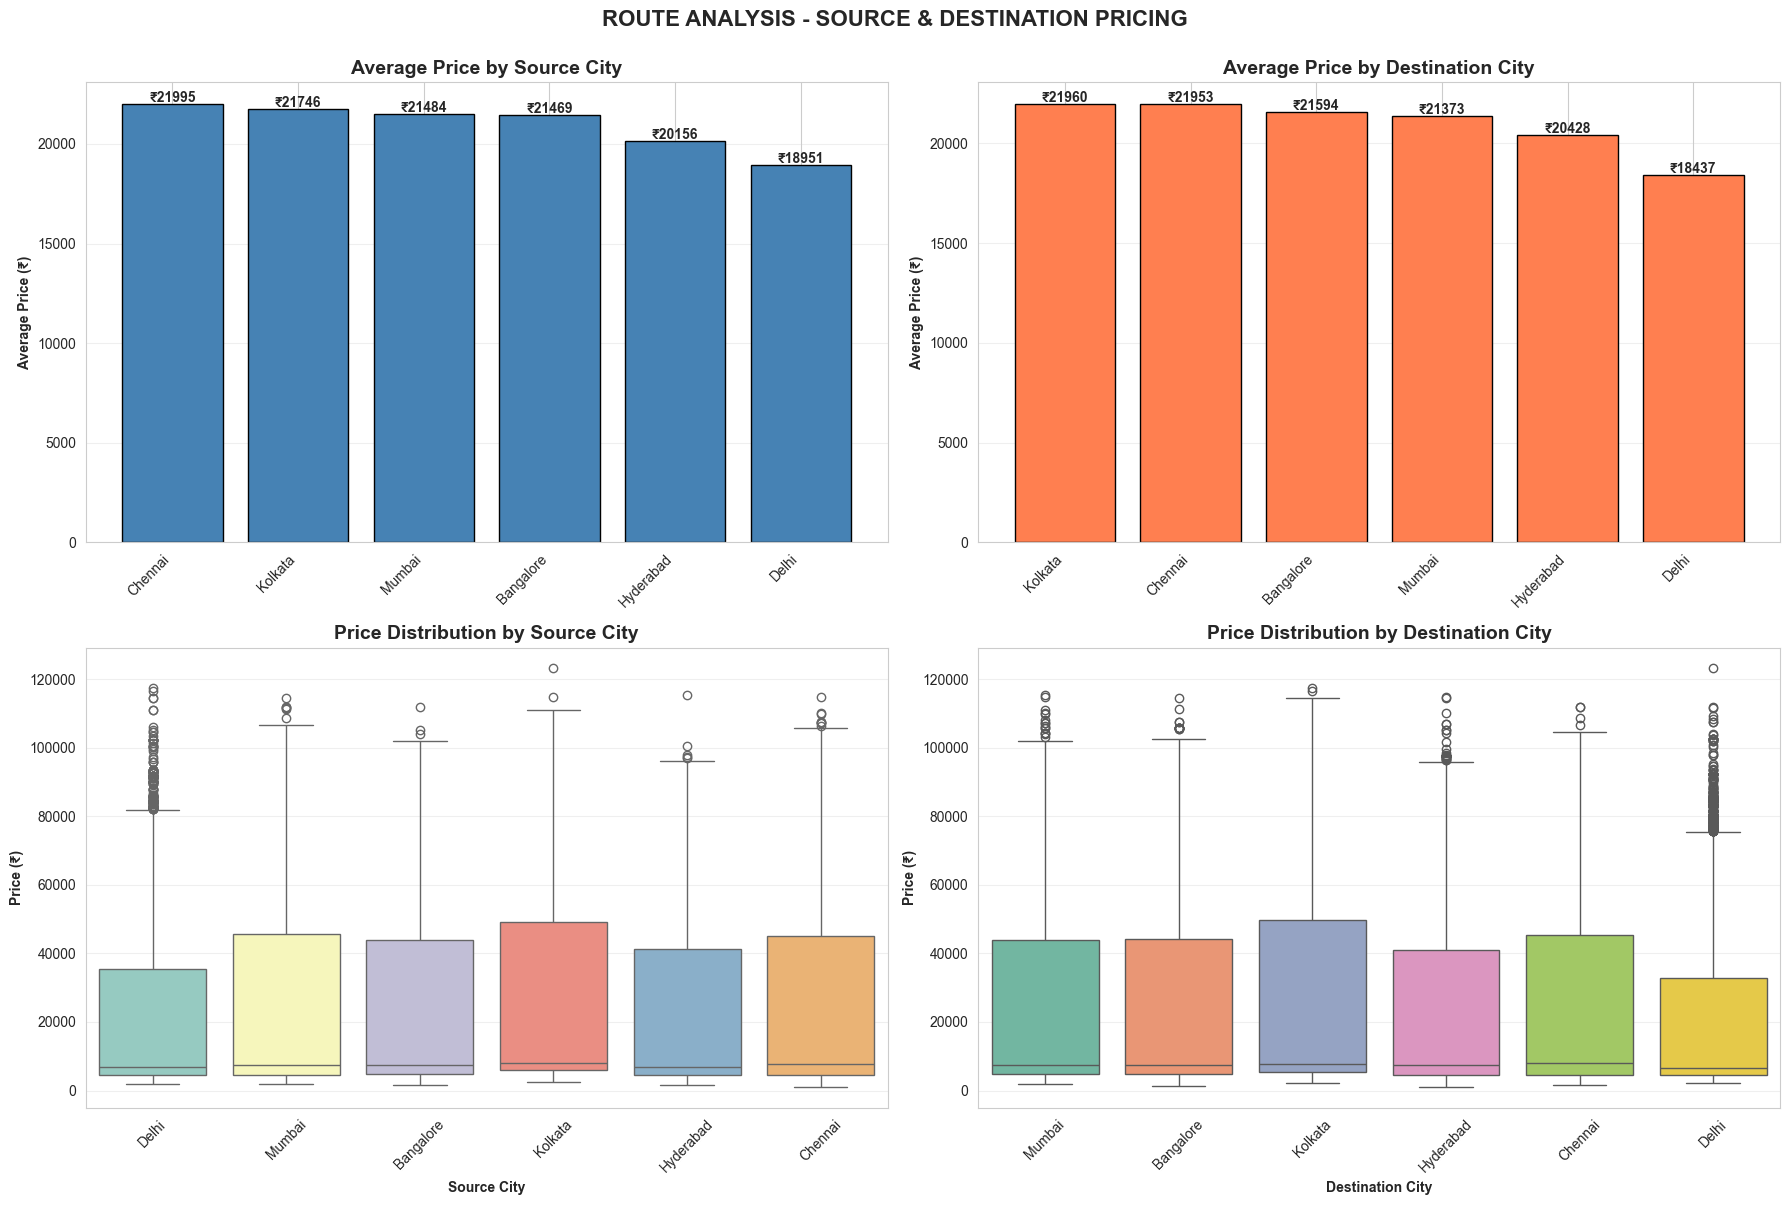

In [48]:
# Visualization - Route Analysis
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Source city average prices
source_mean = df.groupby('source_city')['price'].mean().sort_values(ascending=False)
axes[0, 0].bar(range(len(source_mean)), source_mean.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xticks(range(len(source_mean)))
axes[0, 0].set_xticklabels(source_mean.index, rotation=45, ha='right')
axes[0, 0].set_ylabel('Average Price (₹)', fontweight='bold')
axes[0, 0].set_title('Average Price by Source City', fontweight='bold', fontsize=14)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(source_mean.values):
    axes[0, 0].text(i, v + 100, f'₹{v:.0f}', ha='center', fontweight='bold', fontsize=10)

# Destination city average prices
dest_mean = df.groupby('destination_city')['price'].mean().sort_values(ascending=False)
axes[0, 1].bar(range(len(dest_mean)), dest_mean.values, color='coral', edgecolor='black')
axes[0, 1].set_xticks(range(len(dest_mean)))
axes[0, 1].set_xticklabels(dest_mean.index, rotation=45, ha='right')
axes[0, 1].set_ylabel('Average Price (₹)', fontweight='bold')
axes[0, 1].set_title('Average Price by Destination City', fontweight='bold', fontsize=14)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(dest_mean.values):
    axes[0, 1].text(i, v + 100, f'₹{v:.0f}', ha='center', fontweight='bold', fontsize=10)

# Price distribution by source
sns.boxplot(data=df, x='source_city', y='price', ax=axes[1, 0], palette='Set3')
axes[1, 0].set_xlabel('Source City', fontweight='bold')
axes[1, 0].set_ylabel('Price (₹)', fontweight='bold')
axes[1, 0].set_title('Price Distribution by Source City', fontweight='bold', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Price distribution by destination
sns.boxplot(data=df, x='destination_city', y='price', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_xlabel('Destination City', fontweight='bold')
axes[1, 1].set_ylabel('Price (₹)', fontweight='bold')
axes[1, 1].set_title('Price Distribution by Destination City', fontweight='bold', fontsize=14)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle('ROUTE ANALYSIS - SOURCE & DESTINATION PRICING', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

---
## 4. DEPARTURE & ARRIVAL TIME ANALYSIS
### Examining peak vs off-peak pricing trends

In [49]:
# 4. DEPARTURE & ARRIVAL TIME ANALYSIS
print('\n' + '='*80)
print('4. DEPARTURE & ARRIVAL TIME ANALYSIS')
print('='*80 + '\n')

# Departure time analysis
dep_stats = df.groupby('departure_time')['price'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False)
print('PRICE BY DEPARTURE TIME:')
print('-'*80)
print(dep_stats.round(2))

# Arrival time analysis
arr_stats = df.groupby('arrival_time')['price'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False)
print('\nPRICE BY ARRIVAL TIME:')
print('-'*80)
print(arr_stats.round(2))

# Identify peak and off-peak times
print('\nPEAK vs OFF-PEAK ANALYSIS:')
print('-'*80)
print(f'Most Expensive Departure Time: {dep_stats.index[0]} (₹{dep_stats["mean"].iloc[0]:.2f})')
print(f'Cheapest Departure Time:       {dep_stats.index[-1]} (₹{dep_stats["mean"].iloc[-1]:.2f})')
print(f'\nMost Expensive Arrival Time:   {arr_stats.index[0]} (₹{arr_stats["mean"].iloc[0]:.2f})')
print(f'Cheapest Arrival Time:         {arr_stats.index[-1]} (₹{arr_stats["mean"].iloc[-1]:.2f})')


4. DEPARTURE & ARRIVAL TIME ANALYSIS

PRICE BY DEPARTURE TIME:
--------------------------------------------------------------------------------
                    mean  median       std  count
departure_time                                   
Night           23062.15  7813.0  23617.88  48015
Morning         21630.76  8112.0  22968.91  71146
Evening         21232.36  7425.0  23168.52  65102
Early_Morning   20370.68  7212.0  22354.88  66790
Afternoon       18179.20  6663.0  20928.84  47794
Late_Night       9295.30  4499.0  13680.52   1306

PRICE BY ARRIVAL TIME:
--------------------------------------------------------------------------------
                   mean  median       std  count
arrival_time                                    
Evening        23044.37  8854.0  23494.64  78323
Morning        22231.08  7687.0  23266.08  62735
Night          21586.76  7584.0  23298.01  91538
Afternoon      18494.60  6714.0  20430.01  38139
Early_Morning  14993.14  5800.0  18898.69  15417
Late_Ni

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29216\892207538.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='departure_time', y='price', ax=axes[1, 0], palette='Oranges')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29216\892207538.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='arrival_time', y='price', ax=axes[1, 1], palette='Purples')


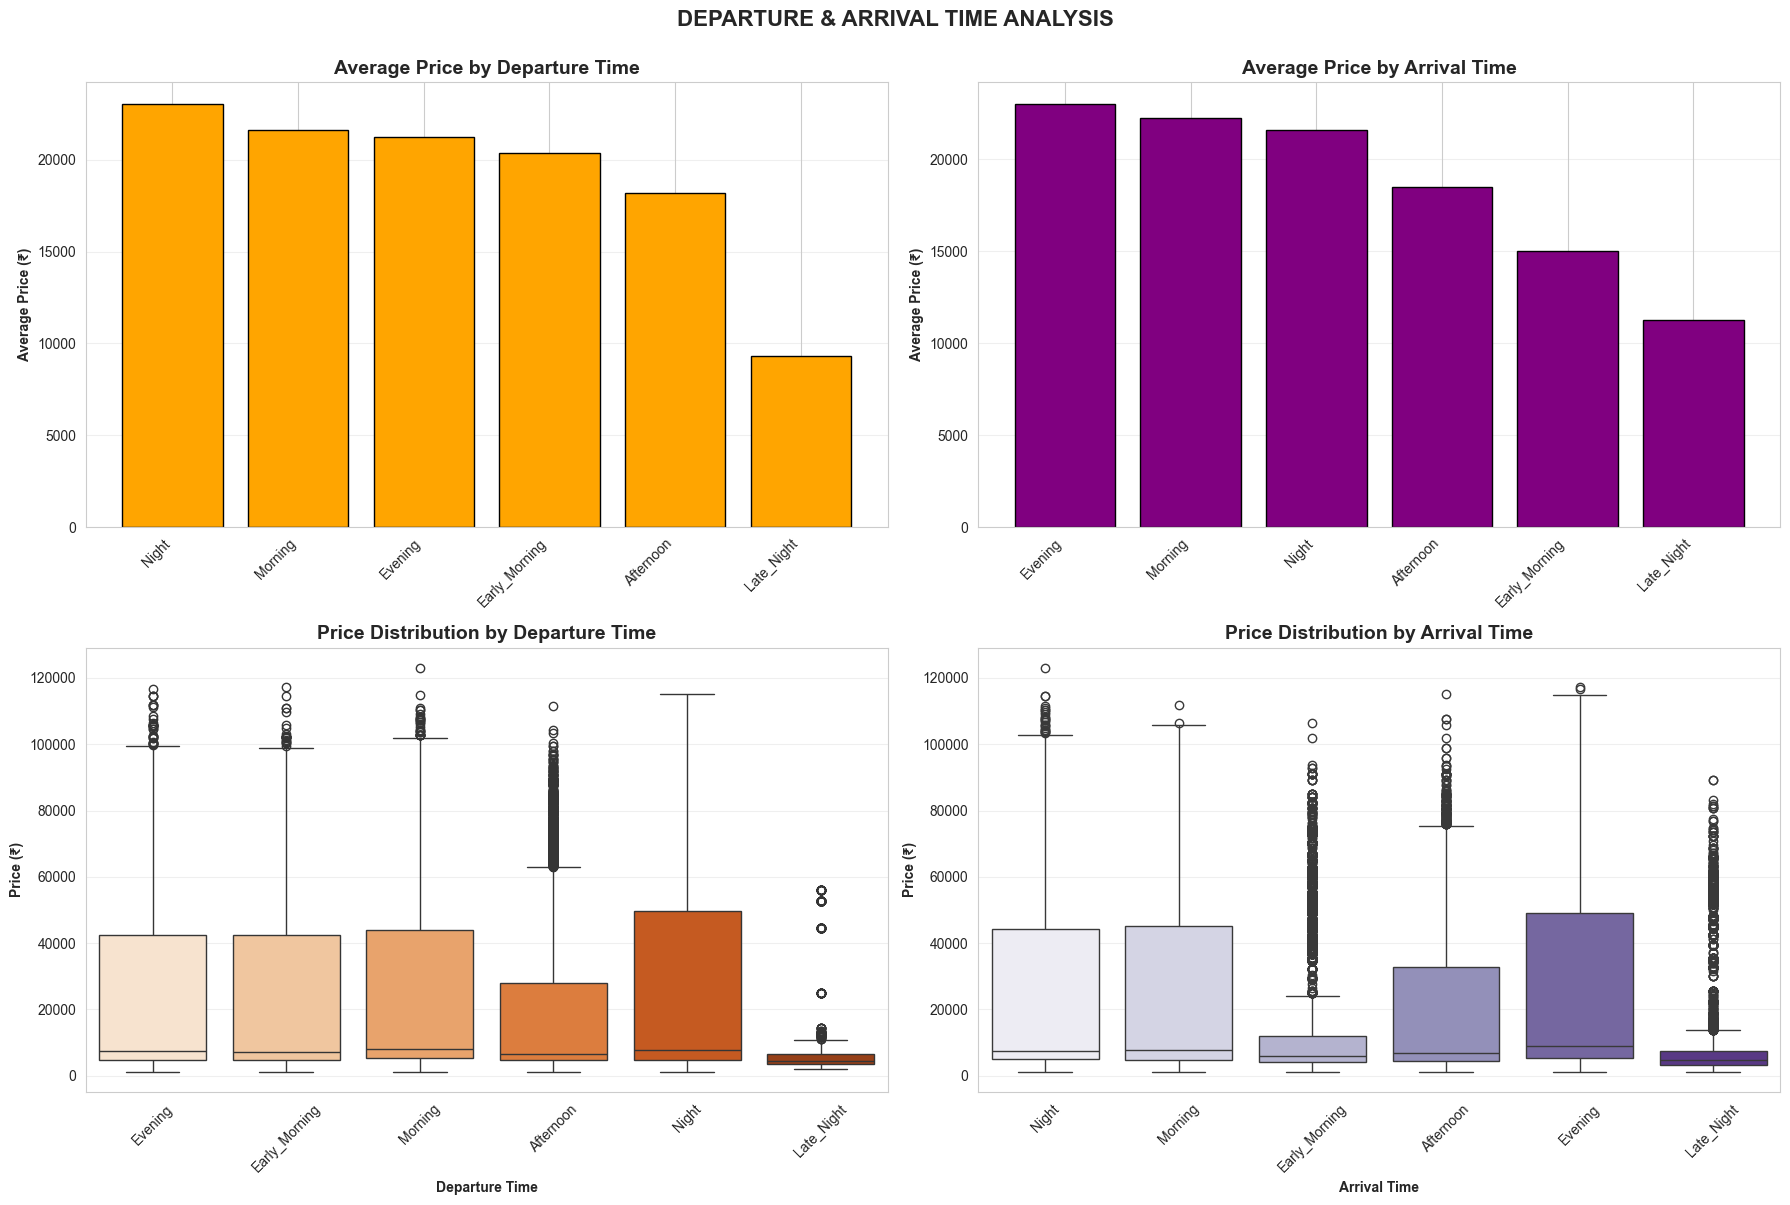

In [50]:
# Visualization - Time Analysis
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Departure time - Average price
dep_mean = df.groupby('departure_time')['price'].mean().sort_values(ascending=False)
axes[0, 0].bar(range(len(dep_mean)), dep_mean.values, color='orange', edgecolor='black')
axes[0, 0].set_xticks(range(len(dep_mean)))
axes[0, 0].set_xticklabels(dep_mean.index, rotation=45, ha='right')
axes[0, 0].set_ylabel('Average Price (₹)', fontweight='bold')
axes[0, 0].set_title('Average Price by Departure Time', fontweight='bold', fontsize=14)
axes[0, 0].grid(axis='y', alpha=0.3)

# Arrival time - Average price
arr_mean = df.groupby('arrival_time')['price'].mean().sort_values(ascending=False)
axes[0, 1].bar(range(len(arr_mean)), arr_mean.values, color='purple', edgecolor='black')
axes[0, 1].set_xticks(range(len(arr_mean)))
axes[0, 1].set_xticklabels(arr_mean.index, rotation=45, ha='right')
axes[0, 1].set_ylabel('Average Price (₹)', fontweight='bold')
axes[0, 1].set_title('Average Price by Arrival Time', fontweight='bold', fontsize=14)
axes[0, 1].grid(axis='y', alpha=0.3)

# Departure time distribution
sns.boxplot(data=df, x='departure_time', y='price', ax=axes[1, 0], palette='Oranges')
axes[1, 0].set_xlabel('Departure Time', fontweight='bold')
axes[1, 0].set_ylabel('Price (₹)', fontweight='bold')
axes[1, 0].set_title('Price Distribution by Departure Time', fontweight='bold', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Arrival time distribution
sns.boxplot(data=df, x='arrival_time', y='price', ax=axes[1, 1], palette='Purples')
axes[1, 1].set_xlabel('Arrival Time', fontweight='bold')
axes[1, 1].set_ylabel('Price (₹)', fontweight='bold')
axes[1, 1].set_title('Price Distribution by Arrival Time', fontweight='bold', fontsize=14)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle('DEPARTURE & ARRIVAL TIME ANALYSIS', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

---
## 5. STOPS ANALYSIS
### Convenience vs cost trade-off

In [51]:
# 5. STOPS ANALYSIS
print('\n' + '='*80)
print('5. STOPS ANALYSIS - CONVENIENCE VS COST')
print('='*80 + '\n')

# Stops analysis
stops_stats = df.groupby('stops')['price'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
stops_order = ['zero', 'one', 'two_or_more']
stops_stats = stops_stats.reindex([s for s in stops_order if s in stops_stats.index])

print('PRICE BY NUMBER OF STOPS:')
print('-'*80)
print(stops_stats.round(2))

# Calculate price premium for non-stop flights
if 'zero' in stops_stats.index and 'one' in stops_stats.index:
    nonstop_premium = stops_stats.loc['zero', 'mean'] - stops_stats.loc['one', 'mean']
    premium_pct = (nonstop_premium / stops_stats.loc['one', 'mean']) * 100
    print(f'\nNON-STOP PREMIUM:')
    print('-'*80)
    print(f'Direct flights cost ₹{abs(nonstop_premium):.2f} ({abs(premium_pct):.1f}%) '
          f'{"MORE" if nonstop_premium > 0 else "LESS"} than 1-stop flights')

# Flight count by stops
print('\nFLIGHT COUNT BY STOPS:')
print('-'*80)
for stop, count in stops_stats['count'].items():
    percentage = (count / len(df)) * 100
    print(f'{stop:15} → {count:5} flights ({percentage:.1f}%)')


5. STOPS ANALYSIS - CONVENIENCE VS COST

PRICE BY NUMBER OF STOPS:
--------------------------------------------------------------------------------
                 mean  median       std   min     max   count
stops                                                        
zero          9375.94  4499.0  10623.01  1105   59573   36004
one          22900.99  7959.0  23626.07  1105  123071  250863
two_or_more  14113.45  8307.0  17664.33  1966  117307   13286

NON-STOP PREMIUM:
--------------------------------------------------------------------------------
Direct flights cost ₹13525.05 (59.1%) LESS than 1-stop flights

FLIGHT COUNT BY STOPS:
--------------------------------------------------------------------------------
zero            → 36004 flights (12.0%)
one             → 250863 flights (83.6%)
two_or_more     → 13286 flights (4.4%)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29216\2232882882.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stops', y='price', ax=axes[1], palette='coolwarm',


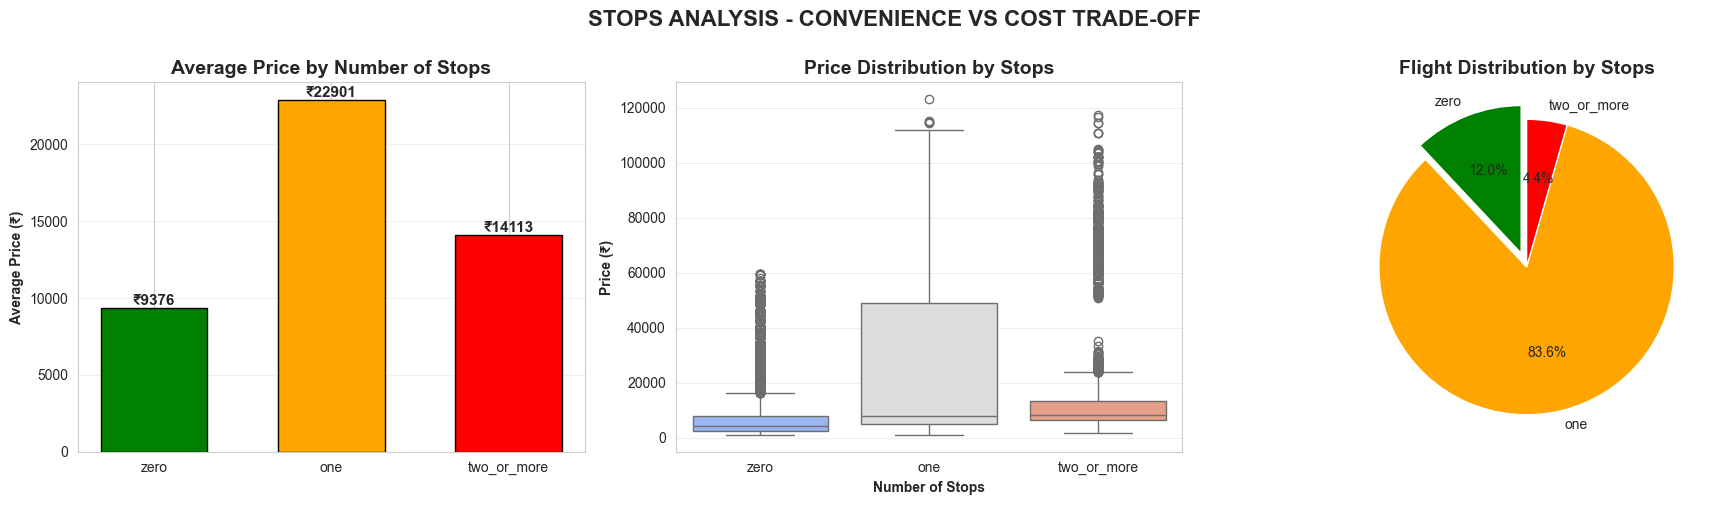

In [52]:
# Visualization - Stops Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Average price by stops
stops_mean = stops_stats['mean']
colors_stops = ['green', 'orange', 'red']
axes[0].bar(range(len(stops_mean)), stops_mean.values, color=colors_stops, edgecolor='black', width=0.6)
axes[0].set_xticks(range(len(stops_mean)))
axes[0].set_xticklabels(stops_mean.index, rotation=0)
axes[0].set_ylabel('Average Price (₹)', fontweight='bold')
axes[0].set_title('Average Price by Number of Stops', fontweight='bold', fontsize=14)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(stops_mean.values):
    axes[0].text(i, v + 200, f'₹{v:.0f}', ha='center', fontweight='bold', fontsize=11)

# Price distribution by stops - Boxplot
sns.boxplot(data=df, x='stops', y='price', ax=axes[1], palette='coolwarm', 
            order=['zero', 'one', 'two_or_more'])
axes[1].set_xlabel('Number of Stops', fontweight='bold')
axes[1].set_ylabel('Price (₹)', fontweight='bold')
axes[1].set_title('Price Distribution by Stops', fontweight='bold', fontsize=14)
axes[1].grid(axis='y', alpha=0.3)

# Count distribution
stops_counts = df['stops'].value_counts().reindex(['zero', 'one', 'two_or_more'])
axes[2].pie(stops_counts.values, labels=stops_counts.index, autopct='%1.1f%%', 
               startangle=90, colors=colors_stops, explode=[0.1, 0, 0])
axes[2].set_title('Flight Distribution by Stops', fontweight='bold', fontsize=14)

plt.suptitle('STOPS ANALYSIS - CONVENIENCE VS COST TRADE-OFF', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

---
## 6. CLASS ANALYSIS
### Comparing price gaps between travel classes

In [53]:
# 6. CLASS ANALYSIS
print('\n' + '='*80)
print('6. CLASS ANALYSIS')
print('='*80 + '\n')

# Class statistics
class_stats = df.groupby('class')['price'].agg(['mean', 'median', 'std', 'min', 'max', 'count']).sort_values('mean', ascending=False)
print('PRICE BY CLASS:')
print('-'*80)
print(class_stats.round(2))

# Class × Airline interaction
class_airline = df.groupby(['class', 'airline'])['price'].mean().unstack(fill_value=0)
print('\nPRICE BY CLASS × AIRLINE:')
print('-'*80)
print(class_airline.round(2))


6. CLASS ANALYSIS

PRICE BY CLASS:
--------------------------------------------------------------------------------
              mean   median       std    min     max   count
class                                                       
Business  52540.08  53164.0  12969.31  12000  123071   93487
Economy    6572.34   5772.0   3743.52   1105   42349  206666

PRICE BY CLASS × AIRLINE:
--------------------------------------------------------------------------------
airline   AirAsia  Air_India  GO_FIRST   Indigo  SpiceJet   Vistara
class                                                              
Business     0.00   47131.04      0.00     0.00      0.00  55477.03
Economy   4091.07    7313.68   5652.01  5324.22   6179.28   7806.94


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29216\374828268.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y='price', ax=axes[1], palette='Set1')


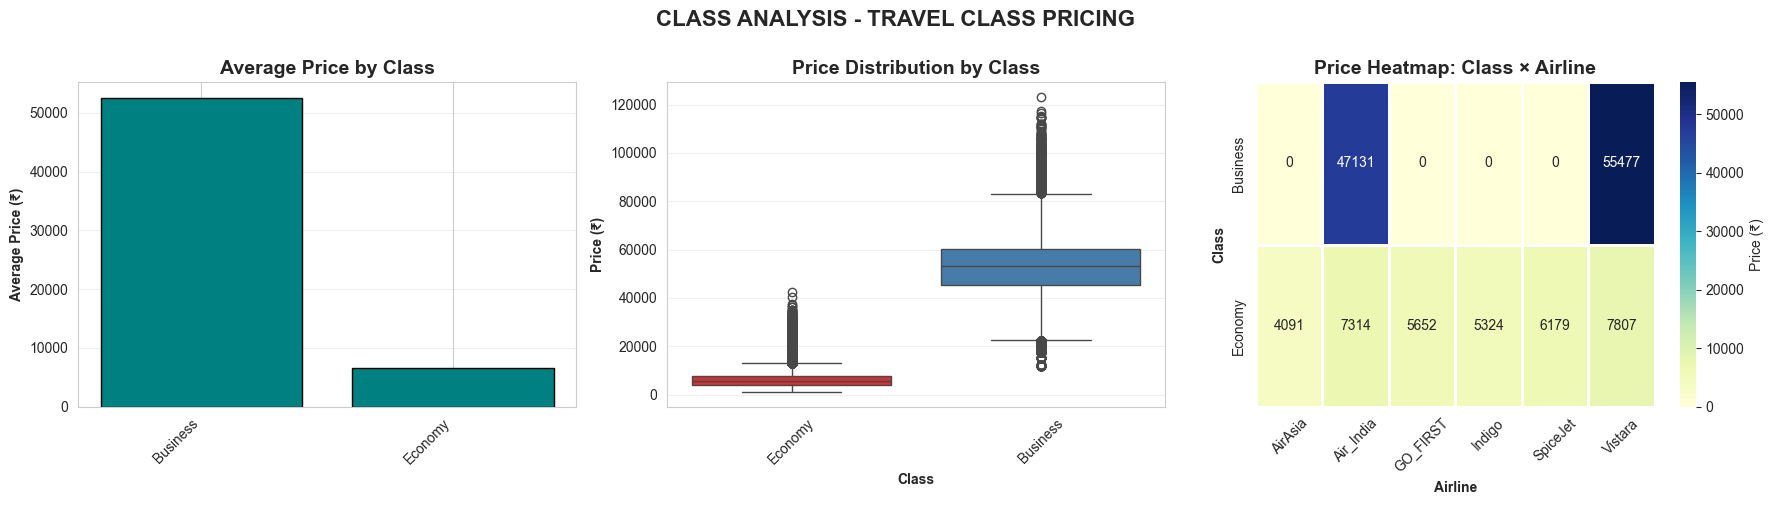

In [54]:
# Visualization - Class Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Average price by class
class_mean = df.groupby('class')['price'].mean().sort_values(ascending=False)
axes[0].bar(range(len(class_mean)), class_mean.values, color='teal', edgecolor='black')
axes[0].set_xticks(range(len(class_mean)))
axes[0].set_xticklabels(class_mean.index, rotation=45, ha='right')
axes[0].set_ylabel('Average Price (₹)', fontweight='bold')
axes[0].set_title('Average Price by Class', fontweight='bold', fontsize=14)
axes[0].grid(axis='y', alpha=0.3)

# Price distribution by class
sns.boxplot(data=df, x='class', y='price', ax=axes[1], palette='Set1')
axes[1].set_xlabel('Class', fontweight='bold')
axes[1].set_ylabel('Price (₹)', fontweight='bold')
axes[1].set_title('Price Distribution by Class', fontweight='bold', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Class × Airline heatmap
sns.heatmap(class_airline, annot=True, fmt='.0f', cmap='YlGnBu', ax=axes[2], 
            linewidths=1, cbar_kws={'label': 'Price (₹)'})
axes[2].set_xlabel('Airline', fontweight='bold')
axes[2].set_ylabel('Class', fontweight='bold')
axes[2].set_title('Price Heatmap: Class × Airline', fontweight='bold', fontsize=14)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('CLASS ANALYSIS - TRAVEL CLASS PRICING', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

---
## 7. DURATION ANALYSIS
### Relationship between flight duration and price

In [55]:
# 7. DURATION ANALYSIS
print('\n' + '='*80)
print('7. DURATION ANALYSIS')
print('='*80 + '\n')

# Correlation between duration and price
duration_price_corr = df['duration'].corr(df['price'])
print(f'CORRELATION: Duration ↔ Price = {duration_price_corr:.4f}')

# Duration statistics
print('\nDURATION STATISTICS:')
print('-'*80)
print(f'Mean Duration:   {df["duration"].mean():.2f} hours')
print(f'Median Duration: {df["duration"].median():.2f} hours')
print(f'Min Duration:    {df["duration"].min():.2f} hours')
print(f'Max Duration:    {df["duration"].max():.2f} hours')

# Create duration bins
df['duration_category'] = pd.cut(df['duration'], 
                                  bins=[0, 3, 6, 12, 50], 
                                  labels=['Short (<3h)', 'Medium (3-6h)', 'Long (6-12h)', 'Very Long (>12h)'])

duration_cat_stats = df.groupby('duration_category')['price'].agg(['mean', 'median', 'count'])
print('\nPRICE BY DURATION CATEGORY:')
print('-'*80)
print(duration_cat_stats.round(2))

# Identify outliers
long_cheap_flights = df[(df['duration'] > 15) & (df['price'] < 8000)]
print(f'\nOUTLIERS: Long Duration (>15h) but Low Price (<₹8000):')
print('-'*80)
print(f'Found {len(long_cheap_flights)} flights')
if len(long_cheap_flights) > 0:
    print(long_cheap_flights[['airline', 'route', 'duration', 'price', 'stops']].head(10))


7. DURATION ANALYSIS

CORRELATION: Duration ↔ Price = 0.2042

DURATION STATISTICS:
--------------------------------------------------------------------------------
Mean Duration:   12.22 hours
Median Duration: 11.25 hours
Min Duration:    0.83 hours
Max Duration:    49.83 hours

PRICE BY DURATION CATEGORY:
--------------------------------------------------------------------------------
                       mean   median   count
duration_category                           
Short (<3h)         9364.92   4498.0   35811
Medium (3-6h)      13336.50   5622.0   25366
Long (6-12h)       19740.42   6883.0  102751
Very Long (>12h)   26192.59  11205.0  136225

OUTLIERS: Long Duration (>15h) but Low Price (<₹8000):
--------------------------------------------------------------------------------
Found 35928 flights
      airline           route  duration  price stops
19    AirAsia  Delhi → Mumbai     16.33   5949   one
22   GO_FIRST  Delhi → Mumbai     15.67   5954   one
148   AirAsia  Delhi → M

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29216\3479395243.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  duration_cat_stats = df.groupby('duration_category')['price'].agg(['mean', 'median', 'count'])


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29216\760319303.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='duration_category', y='price', ax=axes[1, 0],
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29216\760319303.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  duration_cat_mean = df.groupby('duration_category')['price'].mean().reindex(duration_order)


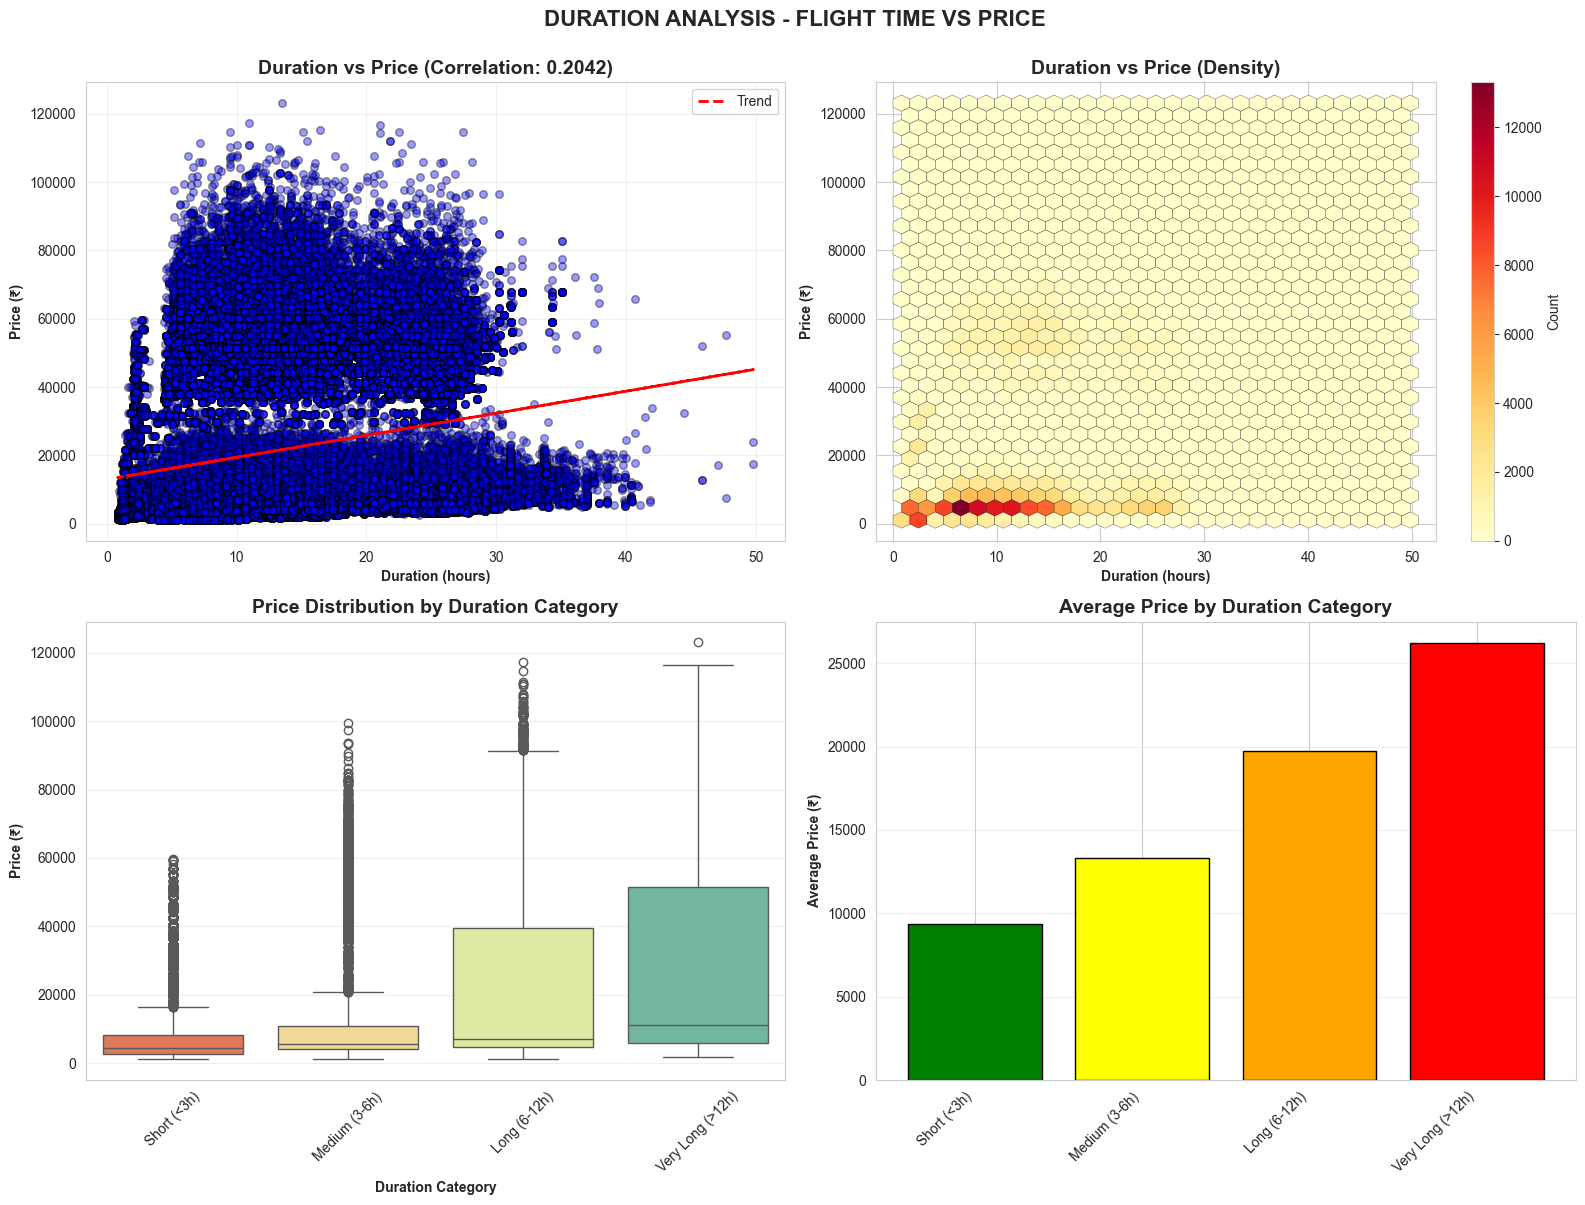

In [56]:
# Visualization - Duration Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Scatter plot: Duration vs Price
axes[0, 0].scatter(df['duration'], df['price'], alpha=0.4, c='blue', edgecolors='black', s=30)
axes[0, 0].set_xlabel('Duration (hours)', fontweight='bold')
axes[0, 0].set_ylabel('Price (₹)', fontweight='bold')
axes[0, 0].set_title(f'Duration vs Price (Correlation: {duration_price_corr:.4f})', fontweight='bold', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)
# Trend line
z = np.polyfit(df['duration'], df['price'], 1)
p = np.poly1d(z)
axes[0, 0].plot(df['duration'], p(df['duration']), "r--", linewidth=2, label='Trend')
axes[0, 0].legend()

# Hexbin density plot
axes[0, 1].hexbin(df['duration'], df['price'], gridsize=30, cmap='YlOrRd', edgecolors='black', linewidths=0.2)
axes[0, 1].set_xlabel('Duration (hours)', fontweight='bold')
axes[0, 1].set_ylabel('Price (₹)', fontweight='bold')
axes[0, 1].set_title('Duration vs Price (Density)', fontweight='bold', fontsize=14)
plt.colorbar(axes[0, 1].collections[0], ax=axes[0, 1], label='Count')

# Price by duration category
duration_order = ['Short (<3h)', 'Medium (3-6h)', 'Long (6-12h)', 'Very Long (>12h)']
sns.boxplot(data=df, x='duration_category', y='price', ax=axes[1, 0], 
            palette='Spectral', order=duration_order)
axes[1, 0].set_xlabel('Duration Category', fontweight='bold')
axes[1, 0].set_ylabel('Price (₹)', fontweight='bold')
axes[1, 0].set_title('Price Distribution by Duration Category', fontweight='bold', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Average price by duration category
duration_cat_mean = df.groupby('duration_category')['price'].mean().reindex(duration_order)
axes[1, 1].bar(range(len(duration_cat_mean)), duration_cat_mean.values, 
               color=['green', 'yellow', 'orange', 'red'], edgecolor='black')
axes[1, 1].set_xticks(range(len(duration_cat_mean)))
axes[1, 1].set_xticklabels(duration_cat_mean.index, rotation=45, ha='right')
axes[1, 1].set_ylabel('Average Price (₹)', fontweight='bold')
axes[1, 1].set_title('Average Price by Duration Category', fontweight='bold', fontsize=14)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle('DURATION ANALYSIS - FLIGHT TIME VS PRICE', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

---
## 8. BOOKING TIME ANALYSIS (days_left)
### Optimal booking window and last-minute pricing

In [57]:
# 8. BOOKING TIME ANALYSIS
print('\n' + '='*80)
print('8. BOOKING TIME ANALYSIS (DAYS LEFT BEFORE DEPARTURE)')
print('='*80 + '\n')

# Correlation
daysleft_price_corr = df['days_left'].corr(df['price'])
print(f'CORRELATION: Days Left ↔ Price = {daysleft_price_corr:.4f}')

# Statistics by days left
daysleft_stats = df.groupby('days_left')['price'].agg(['mean', 'median', 'std', 'min', 'max', 'count']).sort_index()
print('\nPRICE BY DAYS LEFT:')
print('-'*80)
print(daysleft_stats.round(2))

# Identify optimal booking window
cheapest_day = daysleft_stats['mean'].idxmin()
expensive_day = daysleft_stats['mean'].idxmax()

print('\nBOOKING INSIGHTS:')
print('-'*80)
print(f'Cheapest booking:    {cheapest_day} days before (₹{daysleft_stats.loc[cheapest_day, "mean"]:.2f})')
print(f'Most expensive:      {expensive_day} day(s) before (₹{daysleft_stats.loc[expensive_day, "mean"]:.2f})')
price_increase = daysleft_stats.loc[expensive_day, 'mean'] - daysleft_stats.loc[cheapest_day, 'mean']
print(f'Last-minute surge:   ₹{abs(price_increase):.2f} ({abs(price_increase)/daysleft_stats.loc[cheapest_day, "mean"]*100:.1f}%)')


8. BOOKING TIME ANALYSIS (DAYS LEFT BEFORE DEPARTURE)

CORRELATION: Days Left ↔ Price = -0.0919

PRICE BY DAYS LEFT:
--------------------------------------------------------------------------------
               mean   median       std   min     max  count
days_left                                                  
1          21591.87  15163.0  19285.05  4452  116562   1927
2          30211.30  18017.5  24420.92  1977  114523   4026
3          28976.08  16333.0  24621.11  3361  123071   4248
4          25730.91  13054.0  23120.42  3362  110936   5077
5          26679.77  13054.0  24002.60  3361  117307   5392
6          24856.49  12417.5  22200.88  3361  105961   5740
7          25588.37  12990.0  22767.03  3361  105744   5703
8          24895.88  12658.0  21711.80  3361  102114   5767
9          25726.25  13947.0  21533.95  3197   98465   5665
10         25572.82  13303.0  22194.10  3197  107934   5822
11         22990.66  11520.0  21028.96  3197   97045   6417
12         22505.80  

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29216\3207420061.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='days_left', y='price', ax=axes[1, 0], palette='viridis')


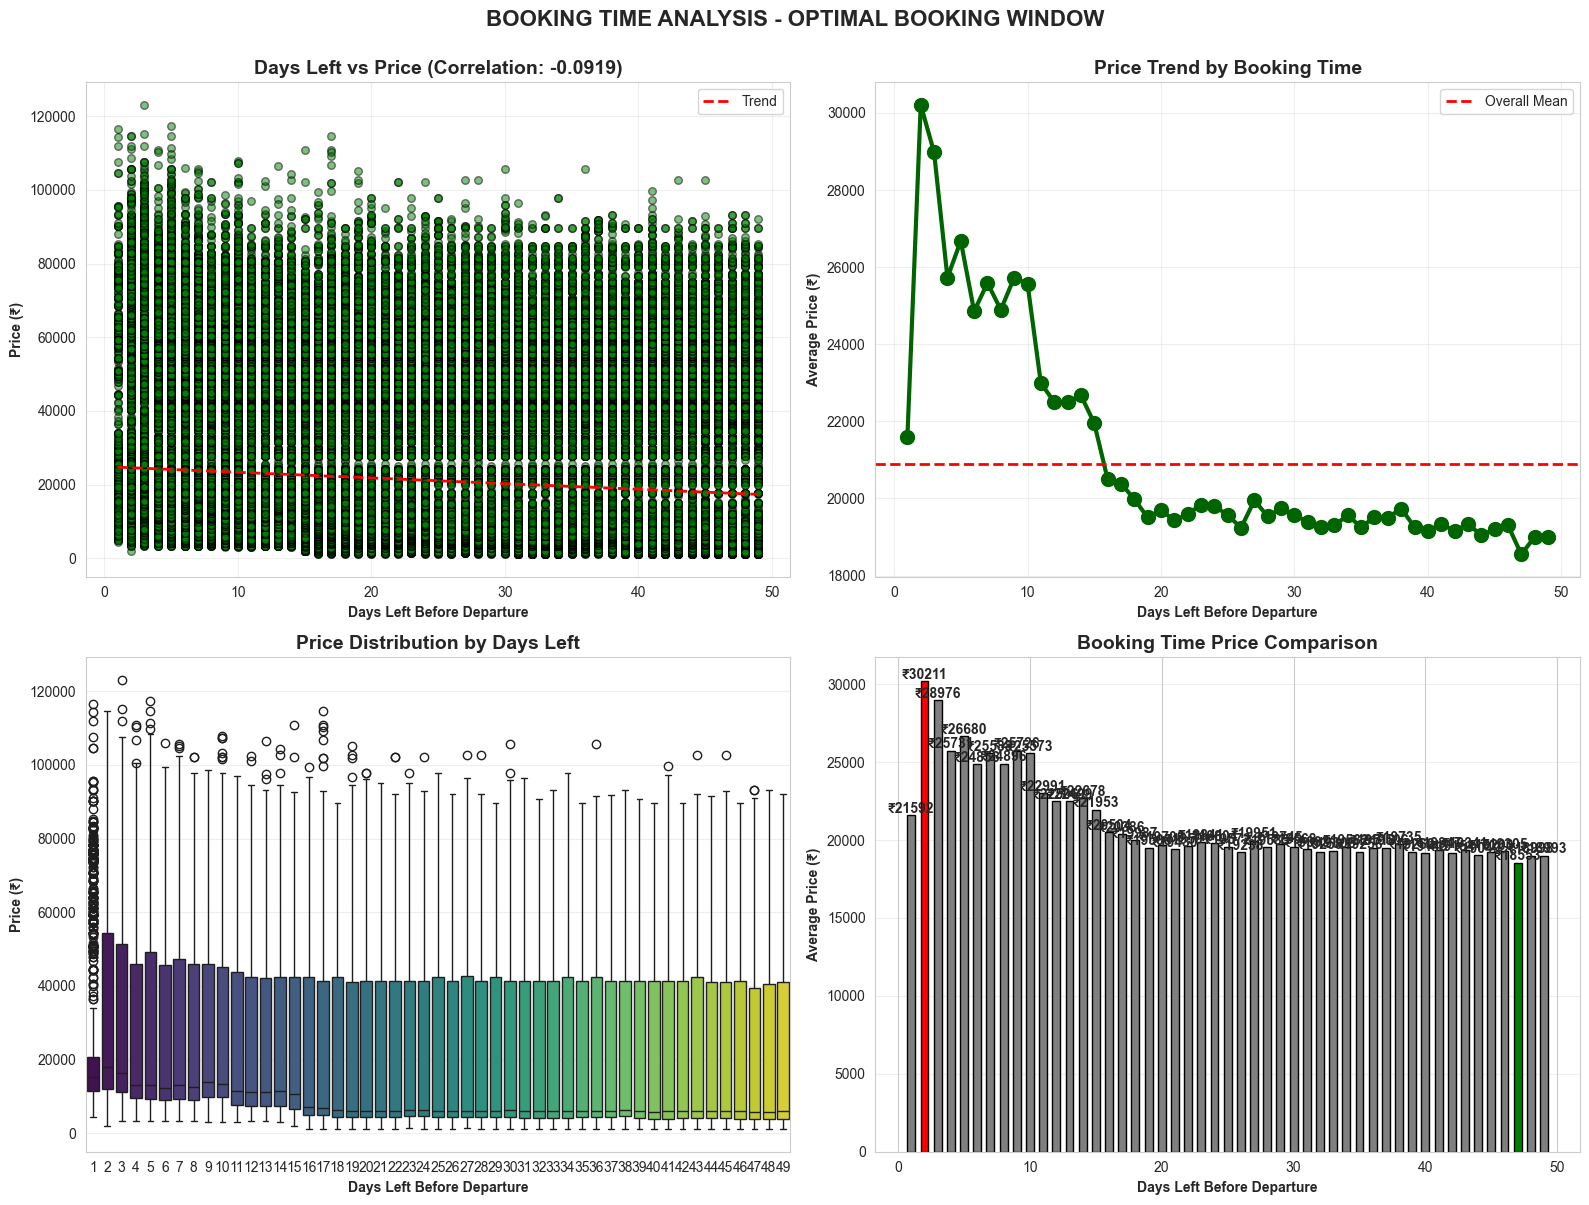

In [58]:
# Visualization - Booking Time Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Scatter plot
axes[0, 0].scatter(df['days_left'], df['price'], alpha=0.5, c='green', edgecolors='black', s=30)
axes[0, 0].set_xlabel('Days Left Before Departure', fontweight='bold')
axes[0, 0].set_ylabel('Price (₹)', fontweight='bold')
axes[0, 0].set_title(f'Days Left vs Price (Correlation: {daysleft_price_corr:.4f})', fontweight='bold', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)
# Trend line
z = np.polyfit(df['days_left'], df['price'], 1)
p = np.poly1d(z)
axes[0, 0].plot(df['days_left'], p(df['days_left']), "r--", linewidth=2, label='Trend')
axes[0, 0].legend()

# Average price by days left
daysleft_mean = df.groupby('days_left')['price'].mean()
axes[0, 1].plot(daysleft_mean.index, daysleft_mean.values, marker='o', linewidth=3, 
                markersize=10, color='darkgreen')
axes[0, 1].set_xlabel('Days Left Before Departure', fontweight='bold')
axes[0, 1].set_ylabel('Average Price (₹)', fontweight='bold')
axes[0, 1].set_title('Price Trend by Booking Time', fontweight='bold', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(df['price'].mean(), color='red', linestyle='--', linewidth=2, label='Overall Mean')
axes[0, 1].legend()

# Boxplot by days left
sns.boxplot(data=df, x='days_left', y='price', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_xlabel('Days Left Before Departure', fontweight='bold')
axes[1, 0].set_ylabel('Price (₹)', fontweight='bold')
axes[1, 0].set_title('Price Distribution by Days Left', fontweight='bold', fontsize=14)
axes[1, 0].grid(axis='y', alpha=0.3)

# Bar chart with comparison
axes[1, 1].bar(daysleft_mean.index, daysleft_mean.values, 
               color=['red' if x == expensive_day else 'green' if x == cheapest_day else 'gray' 
                      for x in daysleft_mean.index], 
               edgecolor='black', width=0.6)
axes[1, 1].set_xlabel('Days Left Before Departure', fontweight='bold')
axes[1, 1].set_ylabel('Average Price (₹)', fontweight='bold')
axes[1, 1].set_title('Booking Time Price Comparison', fontweight='bold', fontsize=14)
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(daysleft_mean.values):
    axes[1, 1].text(daysleft_mean.index[i], v + 150, f'₹{v:.0f}', ha='center', fontweight='bold')

plt.suptitle('BOOKING TIME ANALYSIS - OPTIMAL BOOKING WINDOW', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

---
## 9. INTERACTION EFFECTS & COMBINED ANALYSIS
### Multi-feature interactions and their impact on pricing

In [59]:
# 9. INTERACTION EFFECTS
print('\n' + '='*80)
print('9. INTERACTION EFFECTS & COMBINED ANALYSIS')
print('='*80 + '\n')

# Airline × Class
print('\nINTERACTION: AIRLINE × CLASS')
print('-'*80)
airline_class = df.groupby(['airline', 'class'])['price'].mean().unstack(fill_value=0)
print(airline_class.round(2))

# Stops × Duration Category
print('\n\nINTERACTION: STOPS × DURATION CATEGORY')
print('-'*80)
stops_duration = df.groupby(['stops', 'duration_category'])['price'].mean().unstack(fill_value=0)
print(stops_duration.round(2))

# Days Left × Airline
print('\n\nINTERACTION: DAYS LEFT × AIRLINE')
print('-'*80)
daysleft_airline = df.groupby(['days_left', 'airline'])['price'].mean().unstack(fill_value=0)
print(daysleft_airline.round(2))


9. INTERACTION EFFECTS & COMBINED ANALYSIS


INTERACTION: AIRLINE × CLASS
--------------------------------------------------------------------------------
class      Business  Economy
airline                     
AirAsia        0.00  4091.07
Air_India  47131.04  7313.68
GO_FIRST       0.00  5652.01
Indigo         0.00  5324.22
SpiceJet       0.00  6179.28
Vistara    55477.03  7806.94


INTERACTION: STOPS × DURATION CATEGORY
--------------------------------------------------------------------------------
duration_category  Short (<3h)  Medium (3-6h)  Long (6-12h)  Very Long (>12h)
stops                                                                        
one                   11118.75       13350.81      20147.50          26829.91
two_or_more                NaN       13614.31      13049.68          14974.26
zero                   9364.72       11414.77           NaN               NaN


INTERACTION: DAYS LEFT × AIRLINE
-----------------------------------------------------------------

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29216\378812890.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stops_duration = df.groupby(['stops', 'duration_category'])['price'].mean().unstack(fill_value=0)


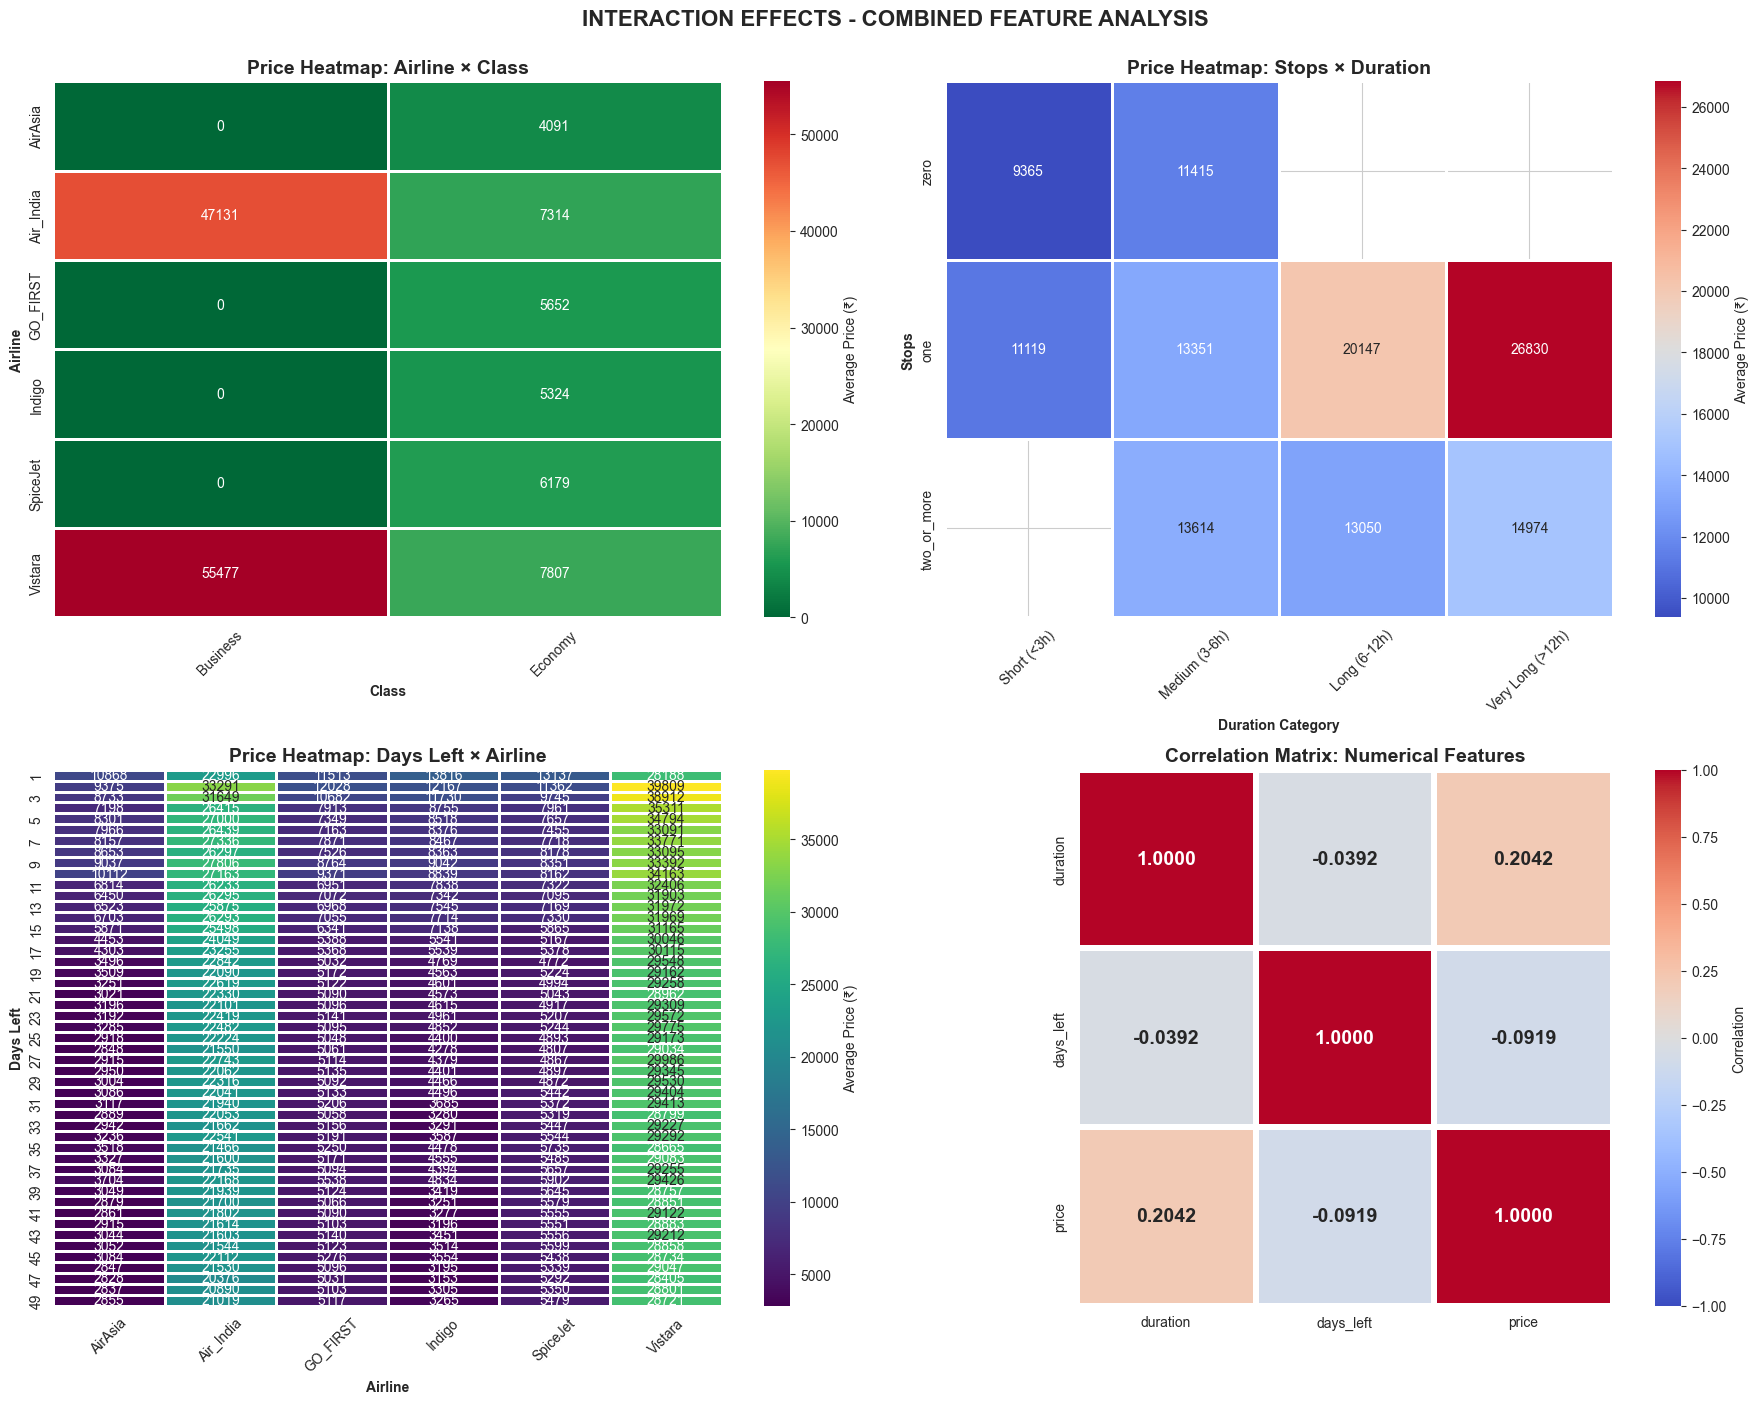

In [60]:
# Visualization - Interaction Effects
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Airline × Class heatmap
sns.heatmap(airline_class, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=axes[0, 0],
            linewidths=1, cbar_kws={'label': 'Average Price (₹)'})
axes[0, 0].set_xlabel('Class', fontweight='bold')
axes[0, 0].set_ylabel('Airline', fontweight='bold')
axes[0, 0].set_title('Price Heatmap: Airline × Class', fontweight='bold', fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=45)

# Stops × Duration heatmap
stops_duration_reindex = stops_duration.reindex(['zero', 'one', 'two_or_more'])
sns.heatmap(stops_duration_reindex, annot=True, fmt='.0f', cmap='coolwarm', ax=axes[0, 1],
            linewidths=1, cbar_kws={'label': 'Average Price (₹)'})
axes[0, 1].set_xlabel('Duration Category', fontweight='bold')
axes[0, 1].set_ylabel('Stops', fontweight='bold')
axes[0, 1].set_title('Price Heatmap: Stops × Duration', fontweight='bold', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=45)

# Days Left × Airline heatmap
sns.heatmap(daysleft_airline, annot=True, fmt='.0f', cmap='viridis', ax=axes[1, 0],
            linewidths=1, cbar_kws={'label': 'Average Price (₹)'})
axes[1, 0].set_xlabel('Airline', fontweight='bold')
axes[1, 0].set_ylabel('Days Left', fontweight='bold')
axes[1, 0].set_title('Price Heatmap: Days Left × Airline', fontweight='bold', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)

# Comprehensive correlation heatmap
numerical_cols = ['duration', 'days_left', 'price']
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='coolwarm', ax=axes[1, 1],
            center=0, square=True, linewidths=3, cbar_kws={'label': 'Correlation'},
            vmin=-1, vmax=1, annot_kws={'size': 14, 'weight': 'bold'})
axes[1, 1].set_title('Correlation Matrix: Numerical Features', fontweight='bold', fontsize=14)

plt.suptitle('INTERACTION EFFECTS - COMBINED FEATURE ANALYSIS', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

---
## 10. KEY INSIGHTS & SUMMARY
### Comprehensive findings from all analyses

In [61]:
# COMPREHENSIVE SUMMARY
print('\n' + '='*80)
print('COMPREHENSIVE EDA SUMMARY - KEY INSIGHTS')
print('='*80 + '\n')

print('1. TARGET VARIABLE (PRICE):')
print(f'   → Mean: ₹{df["price"].mean():.2f}, Median: ₹{df["price"].median():.2f}')
print(f'   → Range: ₹{df["price"].min():.2f} to ₹{df["price"].max():.2f}')
print(f'   → Skewness: {df["price"].skew():.4f} (Right-skewed distribution)')

print('\n2. AIRLINE:')
airline_stats_summary = df.groupby('airline')['price'].mean().sort_values(ascending=False)
print(f'   → Most Expensive: {airline_stats_summary.index[0]} (₹{airline_stats_summary.iloc[0]:.2f})')
print(f'   → Cheapest: {airline_stats_summary.index[-1]} (₹{airline_stats_summary.iloc[-1]:.2f})')

print('\n3. ROUTE:')
route_stats_summary = df.groupby('route')['price'].mean().sort_values(ascending=False)
print(f'   → Most Expensive Route: {route_stats_summary.index[0]} (₹{route_stats_summary.iloc[0]:.2f})')
print(f'   → Cheapest Route: {route_stats_summary.index[-1]} (₹{route_stats_summary.iloc[-1]:.2f})')

print('\n4. DEPARTURE/ARRIVAL TIME:')
dep_stats_summary = df.groupby('departure_time')['price'].mean().sort_values(ascending=False)
print(f'   → Most Expensive Departure: {dep_stats_summary.index[0]} (₹{dep_stats_summary.iloc[0]:.2f})')
print(f'   → Cheapest Departure: {dep_stats_summary.index[-1]} (₹{dep_stats_summary.iloc[-1]:.2f})')

print('\n5. STOPS:')
stops_stats_summary = df.groupby('stops')['price'].mean()
if 'zero' in stops_stats_summary.index and 'one' in stops_stats_summary.index:
    premium = stops_stats_summary['zero'] - stops_stats_summary['one']
    print(f'   → Non-stop premium: ₹{abs(premium):.2f} ({abs(premium)/stops_stats_summary["one"]*100:.1f}%)')

print('\n6. DURATION:')
print(f'   → Correlation with Price: {df["duration"].corr(df["price"]):.4f}')
print(f'   → Mean Duration: {df["duration"].mean():.2f} hours')

print('\n7. BOOKING TIME:')
print(f'   → Correlation with Price: {df["days_left"].corr(df["price"]):.4f}')
daysleft_summary = df.groupby('days_left')['price'].mean()
print(f'   → Cheapest: {daysleft_summary.idxmin()} days before (₹{daysleft_summary.min():.2f})')
print(f'   → Most Expensive: {daysleft_summary.idxmax()} day(s) before (₹{daysleft_summary.max():.2f})')

print('\n' + '='*80)
print('EDA COMPLETE - Ready for Feature Engineering & Modeling')
print('='*80)


COMPREHENSIVE EDA SUMMARY - KEY INSIGHTS

1. TARGET VARIABLE (PRICE):
   → Mean: ₹20889.66, Median: ₹7425.00
   → Range: ₹1105.00 to ₹123071.00
   → Skewness: 1.0614 (Right-skewed distribution)

2. AIRLINE:
   → Most Expensive: Vistara (₹30396.54)
   → Cheapest: AirAsia (₹4091.07)

3. ROUTE:
   → Most Expensive Route: Chennai → Bangalore (₹25081.85)
   → Cheapest Route: Hyderabad → Delhi (₹17243.95)

4. DEPARTURE/ARRIVAL TIME:
   → Most Expensive Departure: Night (₹23062.15)
   → Cheapest Departure: Late_Night (₹9295.30)

5. STOPS:
   → Non-stop premium: ₹13525.05 (59.1%)

6. DURATION:
   → Correlation with Price: 0.2042
   → Mean Duration: 12.22 hours

7. BOOKING TIME:
   → Correlation with Price: -0.0919
   → Cheapest: 47 days before (₹18553.27)
   → Most Expensive: 2 day(s) before (₹30211.30)

EDA COMPLETE - Ready for Feature Engineering & Modeling


In [62]:
# Save cleaned dataframe with new features
df.to_csv('Flight_Data_After_EDA.csv', index=False)
print('\n✓ Enhanced dataset saved as: Flight_Data_After_EDA.csv')
print(f'✓ New features added: {["duration_category", "route"]}')
print('\n✓ Ready for Machine Learning Model Development!')


✓ Enhanced dataset saved as: Flight_Data_After_EDA.csv
✓ New features added: ['duration_category', 'route']

✓ Ready for Machine Learning Model Development!


---
## 11. OUTLIER DETECTION & TREATMENT
### Comprehensive outlier analysis and treatment for regression modeling

In [63]:
# ============================================================================
# OUTLIER DETECTION & TREATMENT FOR FLIGHT PRICE PREDICTION
# Senior Data Scientist Approach - Complete Pipeline
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split

print('='*100)
print('OUTLIER DETECTION & TREATMENT PIPELINE')
print('='*100)

# ----------------------------------------------------------------------------
# STEP 1: DATA PREPARATION
# ----------------------------------------------------------------------------
print('\n[STEP 1] DATA PREPARATION')
print('-'*100)

# Load dataset (assuming df already exists from previous cells)
# If duration_category and route were added during EDA, we might want to drop them for modeling
df_modeling = df.copy()

# Remove any unnamed index columns
unnamed_cols = [col for col in df_modeling.columns if 'Unnamed' in col or 'unnamed' in col]
if unnamed_cols:
    print(f'Dropping unnamed columns: {unnamed_cols}')
    df_modeling = df_modeling.drop(columns=unnamed_cols)

# Separate features and target
target_col = 'price'
if target_col not in df_modeling.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataset!")

# Separate X and y
y = df_modeling[target_col].copy()
X = df_modeling.drop(columns=[target_col]).copy()

print(f'\nDataset shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeatures: {list(X.columns)}')

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f'\n✓ Categorical features ({len(categorical_features)}): {categorical_features}')
print(f'✓ Numerical features ({len(numerical_features)}): {numerical_features}')

# ----------------------------------------------------------------------------
# STEP 2: TRAIN/TEST SPLIT (80/20) - PREVENT DATA LEAKAGE
# ----------------------------------------------------------------------------
print('\n[STEP 2] TRAIN/TEST SPLIT')
print('-'*100)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f'✓ Train set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'✓ Test set:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'✓ Random state: 42 (for reproducibility)')
print(f'\nIMPORTANT: All outlier thresholds will be computed on TRAIN only!')

# ----------------------------------------------------------------------------
# STEP 3: CATEGORICAL FEATURES ANALYSIS (RARE CATEGORIES)
# ----------------------------------------------------------------------------
print('\n[STEP 3] CATEGORICAL FEATURES ANALYSIS')
print('-'*100)

print('\nAnalyzing rare categories (<0.5% of train data)...\n')

rare_categories_report = []
for cat_col in categorical_features:
    print(f'\n{cat_col.upper()}:')
    print('-'*80)
    
    value_counts = X_train[cat_col].value_counts()
    value_pcts = X_train[cat_col].value_counts(normalize=True) * 100
    
    # Display top 10
    for val, count in value_counts.head(10).items():
        pct = value_pcts[val]
        is_rare = '  [RARE]' if pct < 0.5 else ''
        print(f'  {val:30} → {count:6,} ({pct:5.2f}%){is_rare}')
        
        if pct < 0.5:
            rare_categories_report.append({
                'feature': cat_col,
                'category': val,
                'count': count,
                'percent': pct
            })
    
    if len(value_counts) > 10:
        print(f'  ... and {len(value_counts) - 10} more categories')
    
    print(f'  Total unique values: {X_train[cat_col].nunique()}')

if rare_categories_report:
    print(f'\n⚠ Found {len(rare_categories_report)} rare categories across features')
    print('  (Consider grouping these as "Other" during feature engineering)')
else:
    print('\n✓ No rare categories found')

OUTLIER DETECTION & TREATMENT PIPELINE

[STEP 1] DATA PREPARATION
----------------------------------------------------------------------------------------------------
Dropping unnamed columns: ['Unnamed: 0']

Dataset shape: (300153, 12)
Target shape: (300153,)

Features: ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'route', 'duration_category']

✓ Categorical features (10): ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'route', 'duration_category']
✓ Numerical features (2): ['duration', 'days_left']

[STEP 2] TRAIN/TEST SPLIT
----------------------------------------------------------------------------------------------------
✓ Train set: 240,122 samples (80.0%)
✓ Test set:  60,031 samples (20.0%)
✓ Random state: 42 (for reproducibility)

IMPORTANT: All outlier thresholds will be computed on TRAIN only!

[STEP 3] CATEGORICAL FEATURES ANA

In [64]:
# ----------------------------------------------------------------------------
# STEP 4: OUTLIER DETECTION ON NUMERICAL FEATURES (TRAIN ONLY)
# ----------------------------------------------------------------------------
print('\n[STEP 4] OUTLIER DETECTION - NUMERICAL FEATURES')
print('-'*100)

outlier_report = []

for feature in numerical_features:
    print(f'\n{feature.upper()}:')
    print('-'*80)
    
    # Get train data for this feature
    train_data = X_train[feature].copy()
    
    # Compute IQR method bounds
    Q1 = train_data.quantile(0.25)
    Q3 = train_data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outliers_mask = (train_data < lower_bound) | (train_data > upper_bound)
    outlier_count = outliers_mask.sum()
    outlier_percent = (outlier_count / len(train_data)) * 100
    
    # Compute skewness
    skewness = train_data.skew()
    
    # Store in report
    outlier_report.append({
        'feature': feature,
        'method_used': 'IQR (Q1-1.5*IQR, Q3+1.5*IQR)',
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': outlier_count,
        'outlier_percent': outlier_percent,
        'skewness': skewness,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR
    })
    
    # Print statistics
    print(f'  Q1 (25%):        {Q1:.2f}')
    print(f'  Q3 (75%):        {Q3:.2f}')
    print(f'  IQR:             {IQR:.2f}')
    print(f'  Lower bound:     {lower_bound:.2f}')
    print(f'  Upper bound:     {upper_bound:.2f}')
    print(f'  Outliers:        {outlier_count:,} ({outlier_percent:.2f}%)')
    print(f'  Skewness:        {skewness:.4f}')
    
    # Determine treatment method
    if abs(skewness) > 1:
        if train_data.min() >= 0:
            treatment = 'LOG1P TRANSFORM (high skew, non-negative)'
        else:
            treatment = 'WINSORIZATION [1%, 99%] (high skew, has negatives)'
    else:
        treatment = 'IQR CAPPING (low skew)'
    
    print(f'  → Treatment:     {treatment}')

# Create outlier report DataFrame
outlier_report_df = pd.DataFrame(outlier_report)

print('\n' + '='*100)
print('OUTLIER DETECTION SUMMARY')
print('='*100)
print(outlier_report_df.to_string(index=False))
print('='*100)


[STEP 4] OUTLIER DETECTION - NUMERICAL FEATURES
----------------------------------------------------------------------------------------------------

DURATION:
--------------------------------------------------------------------------------
  Q1 (25%):        6.75
  Q3 (75%):        16.17
  IQR:             9.42
  Lower bound:     -7.38
  Upper bound:     30.30
  Outliers:        1,606 (0.67%)
  Skewness:        0.6048
  → Treatment:     IQR CAPPING (low skew)

DAYS_LEFT:
--------------------------------------------------------------------------------
  Q1 (25%):        15.00
  Q3 (75%):        38.00
  IQR:             23.00
  Lower bound:     -19.50
  Upper bound:     72.50
  Outliers:        0 (0.00%)
  Skewness:        -0.0359
  → Treatment:     IQR CAPPING (low skew)

OUTLIER DETECTION SUMMARY
  feature                  method_used  lower_bound  upper_bound  outlier_count  outlier_percent  skewness    Q1    Q3   IQR
 duration IQR (Q1-1.5*IQR, Q3+1.5*IQR)        -7.38         30.3 


[STEP 5] VISUALIZATIONS - BEFORE TREATMENT
----------------------------------------------------------------------------------------------------

Generating plots for: duration


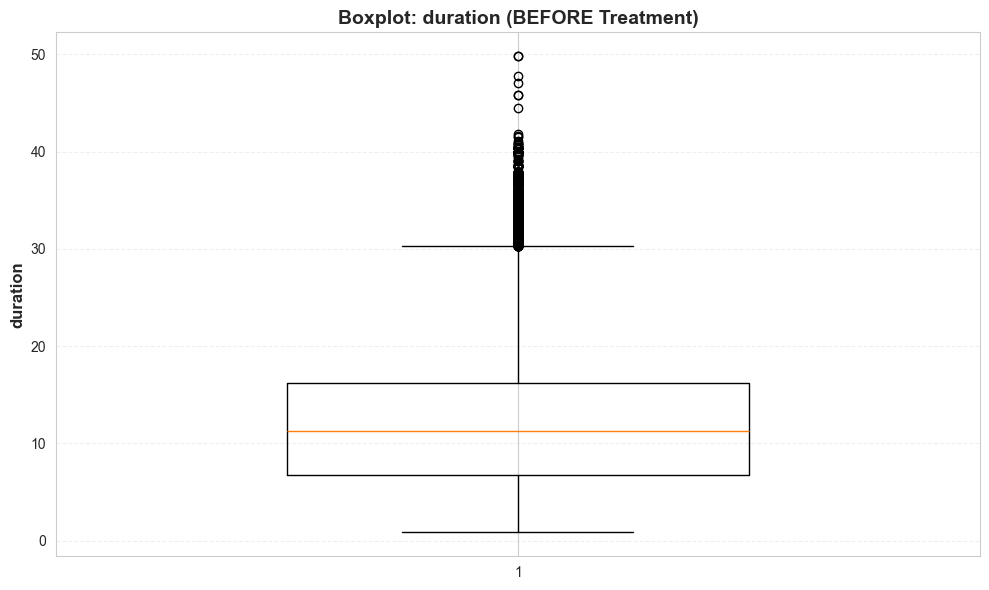

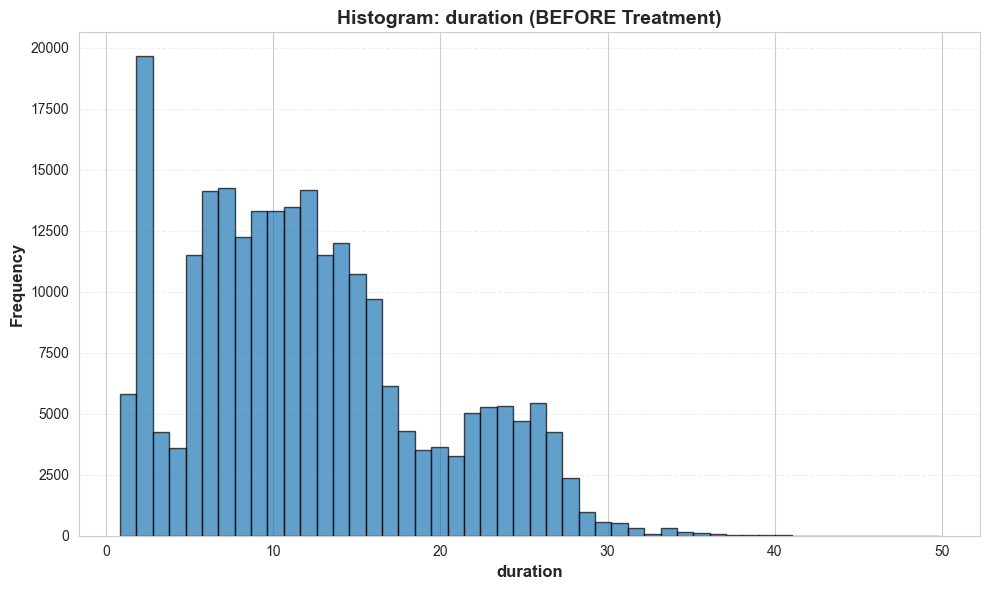

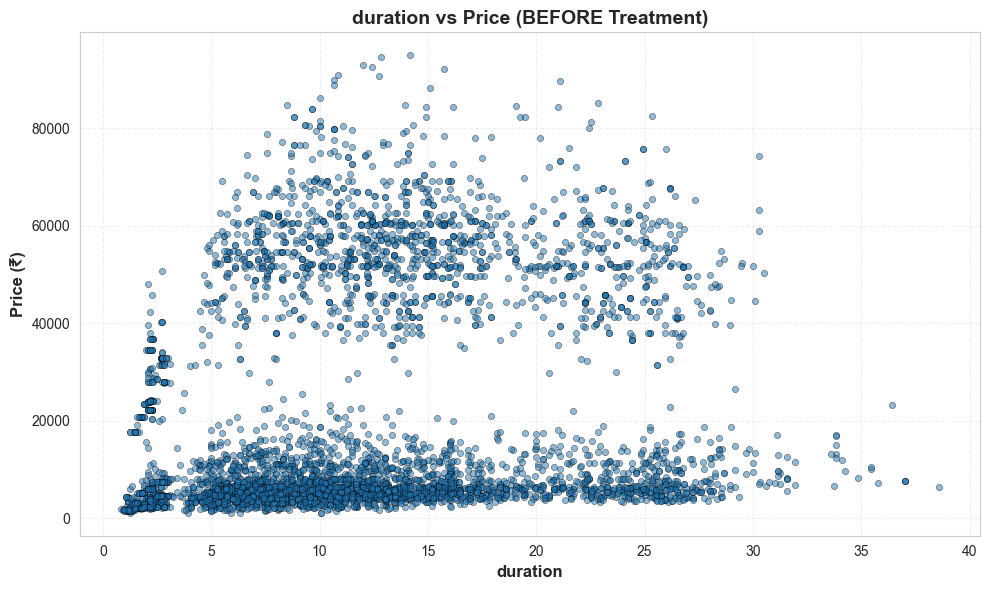


Generating plots for: days_left


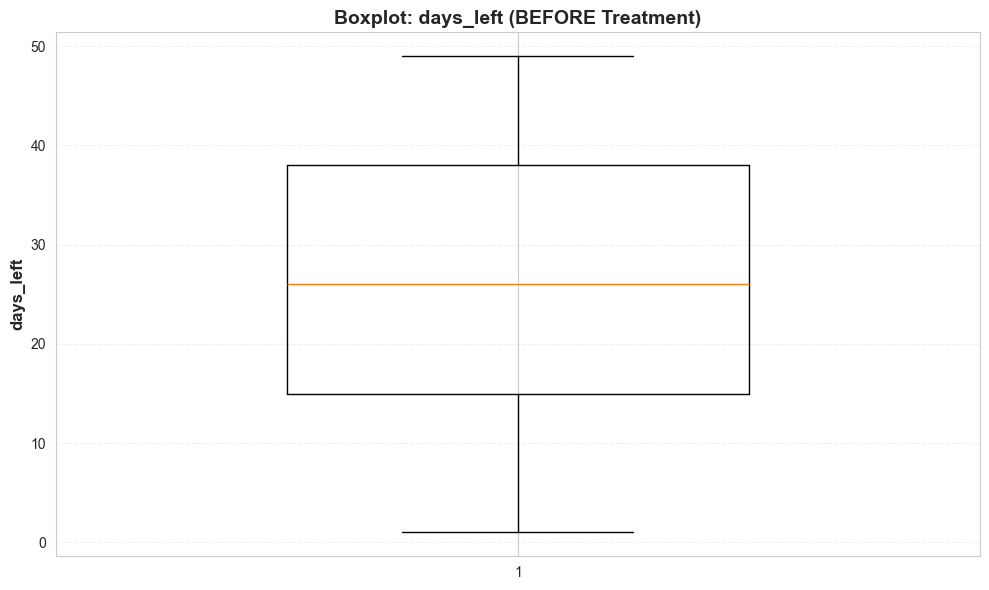

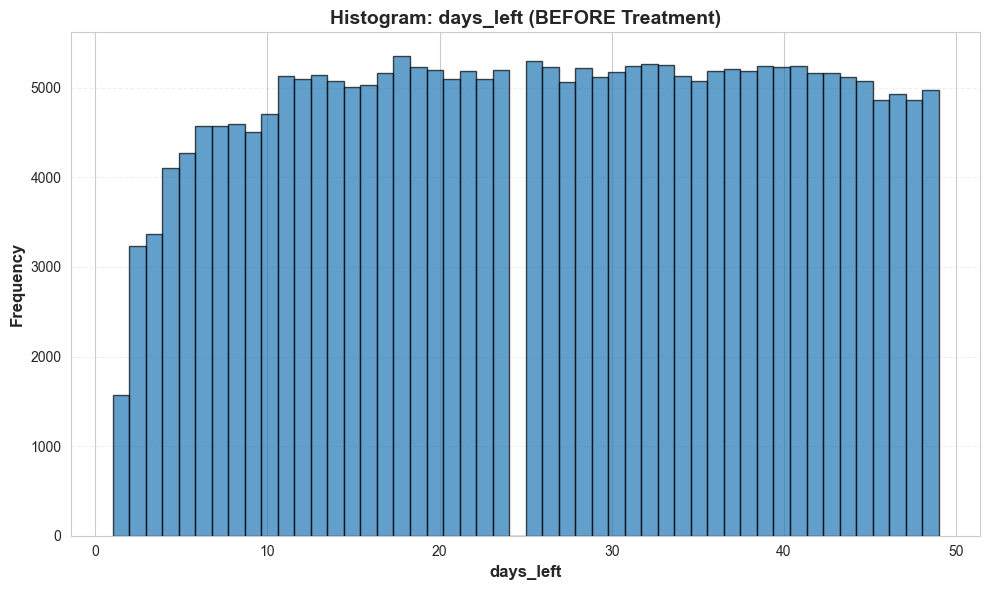

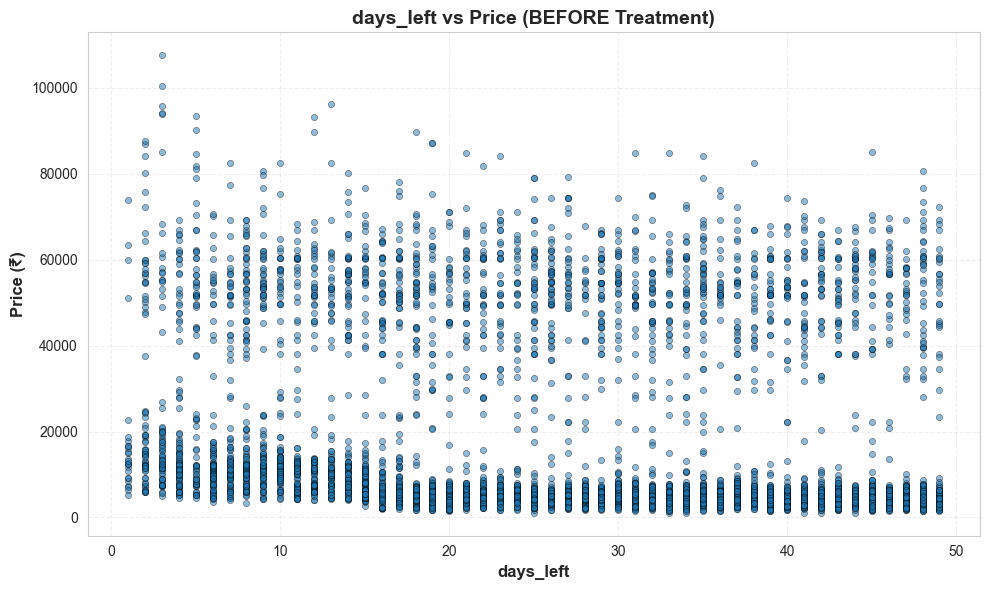


✓ All before-treatment visualizations generated


In [65]:
# ----------------------------------------------------------------------------
# STEP 5: VISUALIZATION - BEFORE TREATMENT
# ----------------------------------------------------------------------------
print('\n[STEP 5] VISUALIZATIONS - BEFORE TREATMENT')
print('-'*100)

for feature in numerical_features:
    print(f'\nGenerating plots for: {feature}')
    
    train_data = X_train[feature].copy()
    
    # Figure 1: Boxplot
    fig1 = plt.figure(figsize=(10, 6))
    plt.boxplot(train_data.dropna(), vert=True, widths=0.5)
    plt.ylabel(feature, fontweight='bold', fontsize=12)
    plt.title(f'Boxplot: {feature} (BEFORE Treatment)', fontweight='bold', fontsize=14)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # Figure 2: Histogram
    fig2 = plt.figure(figsize=(10, 6))
    plt.hist(train_data.dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel(feature, fontweight='bold', fontsize=12)
    plt.ylabel('Frequency', fontweight='bold', fontsize=12)
    plt.title(f'Histogram: {feature} (BEFORE Treatment)', fontweight='bold', fontsize=14)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # Figure 3: Scatter plot (feature vs price) - sample if large
    fig3 = plt.figure(figsize=(10, 6))
    
    # Sample if dataset is large
    if len(X_train) > 5000:
        sample_idx = np.random.choice(len(X_train), 5000, replace=False)
        x_sample = train_data.iloc[sample_idx]
        y_sample = y_train.iloc[sample_idx]
    else:
        x_sample = train_data
        y_sample = y_train
    
    plt.scatter(x_sample, y_sample, alpha=0.5, s=20, edgecolors='black', linewidths=0.5)
    plt.xlabel(feature, fontweight='bold', fontsize=12)
    plt.ylabel('Price (₹)', fontweight='bold', fontsize=12)
    plt.title(f'{feature} vs Price (BEFORE Treatment)', fontweight='bold', fontsize=14)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

print('\n✓ All before-treatment visualizations generated')

In [66]:
# ----------------------------------------------------------------------------
# STEP 6: OUTLIER TREATMENT FUNCTIONS
# ----------------------------------------------------------------------------
print('\n[STEP 6] DEFINING OUTLIER TREATMENT FUNCTIONS')
print('-'*100)

def fit_outlier_handler(X_train, numerical_features):
    """
    Fit outlier handling rules based on TRAIN data only.
    
    Returns a dictionary with treatment rules for each numerical feature:
    - method: 'log1p', 'winsorize', or 'iqr_cap'
    - bounds/quantiles as needed
    """
    handler = {}
    
    for feature in numerical_features:
        train_data = X_train[feature].copy()
        
        # Compute statistics
        Q1 = train_data.quantile(0.25)
        Q3 = train_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        skewness = train_data.skew()
        
        # Decide treatment method
        if abs(skewness) > 1:
            # High skewness
            if train_data.min() >= 0:
                # Non-negative: use log1p
                handler[feature] = {
                    'method': 'log1p',
                    'original_min': train_data.min(),
                    'original_max': train_data.max()
                }
            else:
                # Has negative values: use winsorization
                q01 = train_data.quantile(0.01)
                q99 = train_data.quantile(0.99)
                handler[feature] = {
                    'method': 'winsorize',
                    'lower_quantile': q01,
                    'upper_quantile': q99
                }
        else:
            # Low skewness: use IQR capping
            handler[feature] = {
                'method': 'iqr_cap',
                'lower_bound': lower_bound,
                'upper_bound': upper_bound
            }
    
    return handler


def apply_outlier_handler(X, handler, numerical_features):
    """
    Apply outlier treatment rules to any dataset (train or test).
    
    Returns treated DataFrame.
    """
    X_treated = X.copy()
    
    for feature in numerical_features:
        rule = handler[feature]
        method = rule['method']
        
        if method == 'log1p':
            # Log1p transformation
            X_treated[feature] = np.log1p(X_treated[feature])
            
        elif method == 'winsorize':
            # Clip to 1% and 99% quantiles from train
            lower = rule['lower_quantile']
            upper = rule['upper_quantile']
            X_treated[feature] = X_treated[feature].clip(lower=lower, upper=upper)
            
        elif method == 'iqr_cap':
            # Clip to IQR bounds from train
            lower = rule['lower_bound']
            upper = rule['upper_bound']
            X_treated[feature] = X_treated[feature].clip(lower=lower, upper=upper)
    
    return X_treated


print('✓ Functions defined:')
print('  → fit_outlier_handler(X_train, numerical_features)')
print('  → apply_outlier_handler(X, handler, numerical_features)')


[STEP 6] DEFINING OUTLIER TREATMENT FUNCTIONS
----------------------------------------------------------------------------------------------------
✓ Functions defined:
  → fit_outlier_handler(X_train, numerical_features)
  → apply_outlier_handler(X, handler, numerical_features)


In [67]:
# ----------------------------------------------------------------------------
# STEP 7: APPLY OUTLIER TREATMENT
# ----------------------------------------------------------------------------
print('\n[STEP 7] APPLYING OUTLIER TREATMENT')
print('-'*100)

# Fit handler on TRAIN only
print('\n✓ Fitting outlier handler on TRAIN data...')
handler = fit_outlier_handler(X_train, numerical_features)

# Show treatment plan
print('\nTREATMENT PLAN:')
print('-'*80)
for feature, rule in handler.items():
    method = rule['method']
    print(f'{feature:20} → {method.upper():15}', end='')
    
    if method == 'log1p':
        print(f' (range: {rule["original_min"]:.2f} to {rule["original_max"]:.2f})')
    elif method == 'winsorize':
        print(f' (clip: {rule["lower_quantile"]:.2f} to {rule["upper_quantile"]:.2f})')
    elif method == 'iqr_cap':
        print(f' (clip: {rule["lower_bound"]:.2f} to {rule["upper_bound"]:.2f})')

# Apply to TRAIN
print('\n✓ Applying treatment to TRAIN set...')
X_train_clean = apply_outlier_handler(X_train, handler, numerical_features)

# Apply to TEST (using TRAIN-derived rules)
print('✓ Applying treatment to TEST set (using TRAIN rules)...')
X_test_clean = apply_outlier_handler(X_test, handler, numerical_features)

print('\n✓ Treatment complete!')
print(f'  → X_train_clean: {X_train_clean.shape}')
print(f'  → X_test_clean:  {X_test_clean.shape}')
print(f'  → y_train:       {y_train.shape}')
print(f'  → y_test:        {y_test.shape}')


[STEP 7] APPLYING OUTLIER TREATMENT
----------------------------------------------------------------------------------------------------

✓ Fitting outlier handler on TRAIN data...

TREATMENT PLAN:
--------------------------------------------------------------------------------
duration             → IQR_CAP         (clip: -7.38 to 30.30)
days_left            → IQR_CAP         (clip: -19.50 to 72.50)

✓ Applying treatment to TRAIN set...
✓ Applying treatment to TEST set (using TRAIN rules)...

✓ Treatment complete!
  → X_train_clean: (240122, 12)
  → X_test_clean:  (60031, 12)
  → y_train:       (240122,)
  → y_test:        (60031,)


In [68]:
# ----------------------------------------------------------------------------
# STEP 8: VERIFICATION - BEFORE vs AFTER COMPARISON
# ----------------------------------------------------------------------------
print('\n[STEP 8] VERIFICATION - OUTLIER REDUCTION')
print('-'*100)

before_after_summary = []

for feature in numerical_features:
    # BEFORE (original train)
    train_data_before = X_train[feature].copy()
    Q1_before = train_data_before.quantile(0.25)
    Q3_before = train_data_before.quantile(0.75)
    IQR_before = Q3_before - Q1_before
    lower_before = Q1_before - 1.5 * IQR_before
    upper_before = Q3_before + 1.5 * IQR_before
    outliers_before = ((train_data_before < lower_before) | (train_data_before > upper_before)).sum()
    pct_before = (outliers_before / len(train_data_before)) * 100
    
    # AFTER (treated train)
    train_data_after = X_train_clean[feature].copy()
    Q1_after = train_data_after.quantile(0.25)
    Q3_after = train_data_after.quantile(0.75)
    IQR_after = Q3_after - Q1_after
    lower_after = Q1_after - 1.5 * IQR_after
    upper_after = Q3_after + 1.5 * IQR_after
    outliers_after = ((train_data_after < lower_after) | (train_data_after > upper_after)).sum()
    pct_after = (outliers_after / len(train_data_after)) * 100
    
    # Reduction
    reduction = outliers_before - outliers_after
    reduction_pct = ((outliers_before - outliers_after) / outliers_before * 100) if outliers_before > 0 else 0
    
    before_after_summary.append({
        'feature': feature,
        'outliers_before': outliers_before,
        'pct_before': pct_before,
        'outliers_after': outliers_after,
        'pct_after': pct_after,
        'reduction': reduction,
        'reduction_pct': reduction_pct
    })
    
    print(f'\n{feature.upper()}:')
    print('-'*80)
    print(f'  Before: {outliers_before:,} outliers ({pct_before:.2f}%)')
    print(f'  After:  {outliers_after:,} outliers ({pct_after:.2f}%)')
    print(f'  Reduced: {reduction:,} outliers ({reduction_pct:.1f}% reduction)')

# Create summary DataFrame
before_after_df = pd.DataFrame(before_after_summary)

print('\n' + '='*100)
print('BEFORE vs AFTER SUMMARY')
print('='*100)
print(before_after_df.to_string(index=False))
print('='*100)


[STEP 8] VERIFICATION - OUTLIER REDUCTION
----------------------------------------------------------------------------------------------------

DURATION:
--------------------------------------------------------------------------------
  Before: 1,606 outliers (0.67%)
  After:  0 outliers (0.00%)
  Reduced: 1,606 outliers (100.0% reduction)

DAYS_LEFT:
--------------------------------------------------------------------------------
  Before: 0 outliers (0.00%)
  After:  0 outliers (0.00%)
  Reduced: 0 outliers (0.0% reduction)

BEFORE vs AFTER SUMMARY
  feature  outliers_before  pct_before  outliers_after  pct_after  reduction  reduction_pct
 duration             1606    0.668827               0        0.0       1606          100.0
days_left                0    0.000000               0        0.0          0            0.0



[STEP 9] VISUALIZATIONS - AFTER TREATMENT
----------------------------------------------------------------------------------------------------

Generating after-treatment plots for: duration


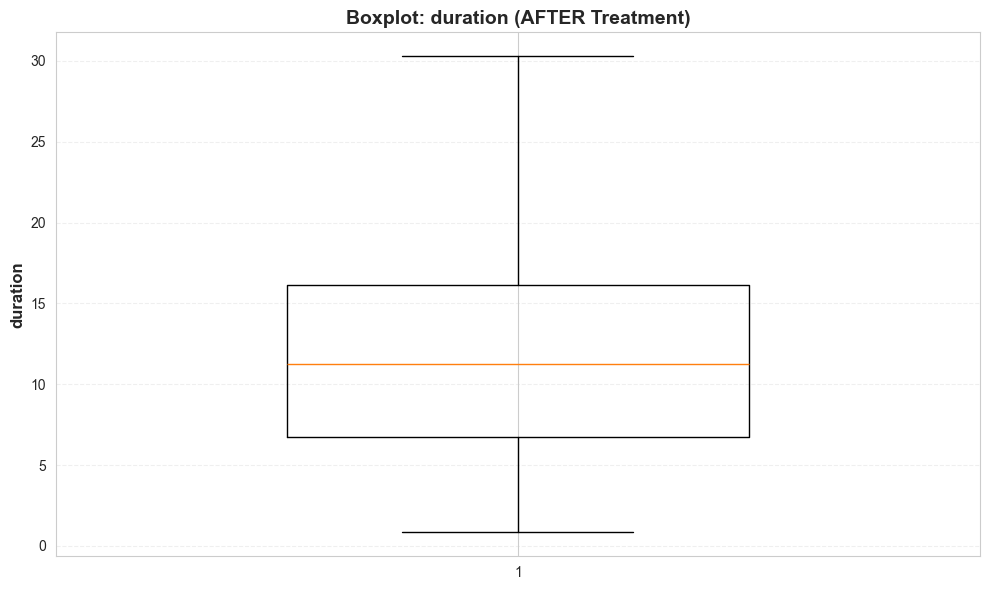

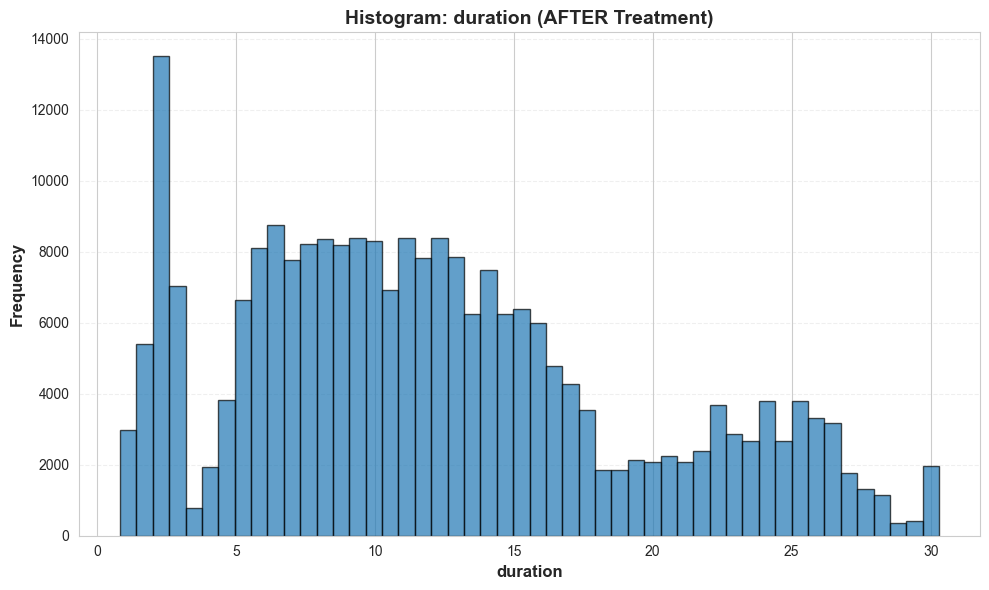


Generating after-treatment plots for: days_left


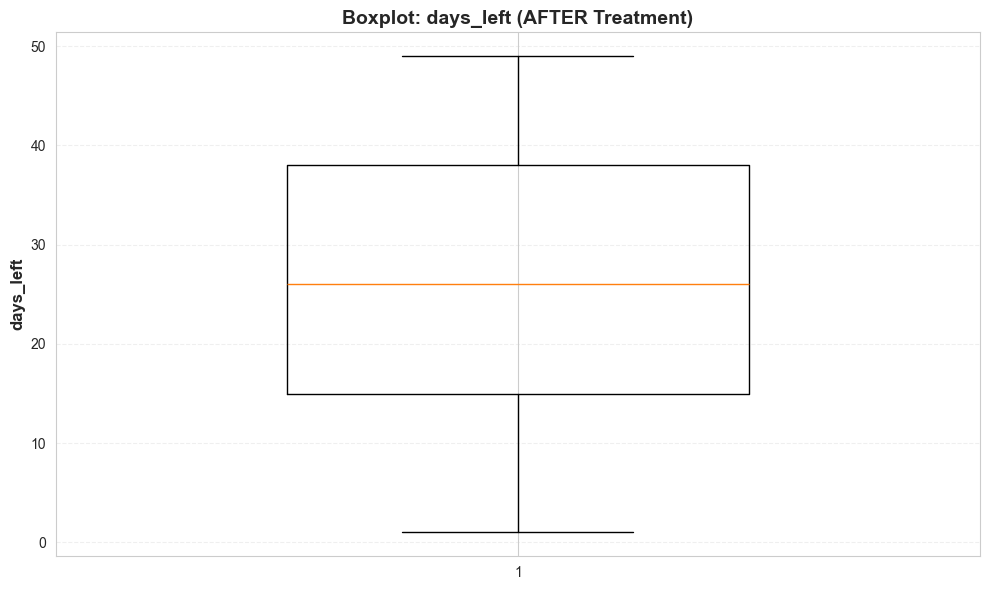

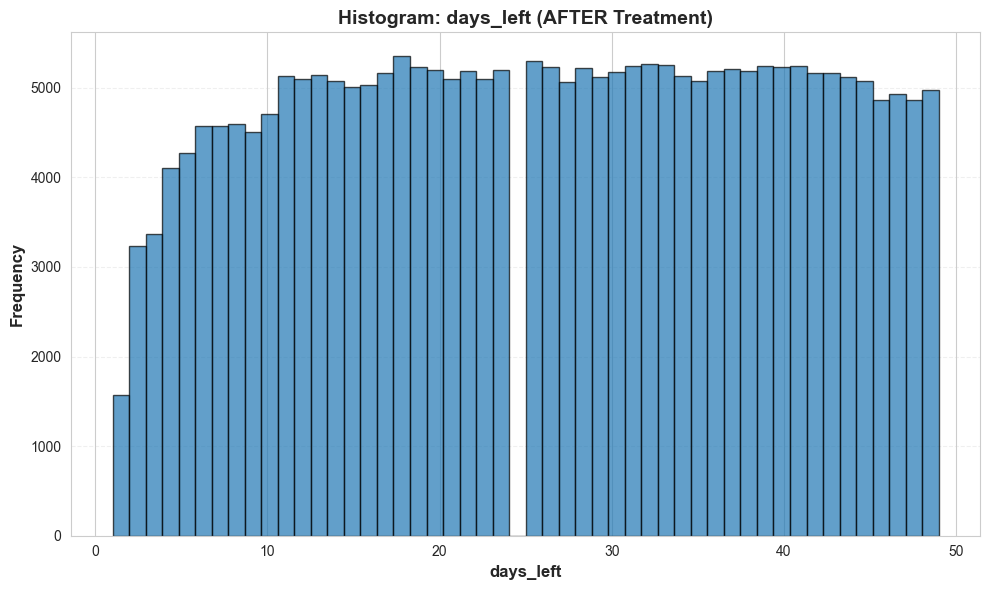


✓ All after-treatment visualizations generated


In [69]:
# ----------------------------------------------------------------------------
# STEP 9: VISUALIZATION - AFTER TREATMENT
# ----------------------------------------------------------------------------
print('\n[STEP 9] VISUALIZATIONS - AFTER TREATMENT')
print('-'*100)

for feature in numerical_features:
    print(f'\nGenerating after-treatment plots for: {feature}')
    
    train_data_after = X_train_clean[feature].copy()
    
    # Figure 1: Boxplot AFTER
    fig1 = plt.figure(figsize=(10, 6))
    plt.boxplot(train_data_after.dropna(), vert=True, widths=0.5)
    plt.ylabel(feature, fontweight='bold', fontsize=12)
    plt.title(f'Boxplot: {feature} (AFTER Treatment)', fontweight='bold', fontsize=14)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # Figure 2: Histogram AFTER
    fig2 = plt.figure(figsize=(10, 6))
    plt.hist(train_data_after.dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel(feature, fontweight='bold', fontsize=12)
    plt.ylabel('Frequency', fontweight='bold', fontsize=12)
    plt.title(f'Histogram: {feature} (AFTER Treatment)', fontweight='bold', fontsize=14)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

print('\n✓ All after-treatment visualizations generated')

In [70]:
# ----------------------------------------------------------------------------
# STEP 10: FINAL SUMMARY & OUTPUT
# ----------------------------------------------------------------------------
print('\n[STEP 10] FINAL SUMMARY')
print('='*100)

print('\n✓ OUTLIER TREATMENT COMPLETED SUCCESSFULLY!')
print('\n' + '='*100)
print('KEY OUTPUTS:')
print('='*100)

print('\n1. CLEANED DATASETS:')
print('-'*100)
print(f'   X_train_clean: {X_train_clean.shape[0]:,} samples × {X_train_clean.shape[1]} features')
print(f'   X_test_clean:  {X_test_clean.shape[0]:,} samples × {X_test_clean.shape[1]} features')
print(f'   y_train:       {y_train.shape[0]:,} samples')
print(f'   y_test:        {y_test.shape[0]:,} samples')

print('\n2. TREATMENT METHODS APPLIED:')
print('-'*100)
for feature, rule in handler.items():
    print(f'   {feature:20} → {rule["method"].upper()}')

print('\n3. OUTLIER REDUCTION:')
print('-'*100)
total_outliers_before = before_after_df['outliers_before'].sum()
total_outliers_after = before_after_df['outliers_after'].sum()
total_reduction = total_outliers_before - total_outliers_after
total_reduction_pct = (total_reduction / total_outliers_before * 100) if total_outliers_before > 0 else 0

print(f'   Total outliers before: {total_outliers_before:,}')
print(f'   Total outliers after:  {total_outliers_after:,}')
print(f'   Total reduction:       {total_reduction:,} ({total_reduction_pct:.1f}%)')

print('\n4. REPORTS AVAILABLE:')
print('-'*100)
print(f'   outlier_report_df:     Initial outlier detection ({len(outlier_report_df)} features)')
print(f'   before_after_df:       Before/after comparison ({len(before_after_df)} features)')
print(f'   handler:               Treatment rules dictionary')

print('\n5. NO ROWS DROPPED:')
print('-'*100)
print(f'   ✓ All {X_train_clean.shape[0]:,} training samples retained')
print(f'   ✓ All {X_test_clean.shape[0]:,} test samples retained')
print('   ✓ Only outlier values were capped/transformed, not removed')

print('\n6. DATA LEAKAGE PREVENTION:')
print('-'*100)
print('   ✓ All thresholds computed on TRAIN set only')
print('   ✓ Same rules applied consistently to TEST set')
print('   ✓ No information from TEST used during treatment')

print('\n' + '='*100)
print('READY FOR MODELING!')
print('='*100)
print('\nNext steps:')
print('  → Encode categorical features (airline, source_city, etc.)')
print('  → Scale/normalize features if needed')
print('  → Train regression model (LinearRegression, RandomForest, XGBoost, etc.)')
print('  → Evaluate on test set')
print('\n' + '='*100)


[STEP 10] FINAL SUMMARY

✓ OUTLIER TREATMENT COMPLETED SUCCESSFULLY!

KEY OUTPUTS:

1. CLEANED DATASETS:
----------------------------------------------------------------------------------------------------
   X_train_clean: 240,122 samples × 12 features
   X_test_clean:  60,031 samples × 12 features
   y_train:       240,122 samples
   y_test:        60,031 samples

2. TREATMENT METHODS APPLIED:
----------------------------------------------------------------------------------------------------
   duration             → IQR_CAP
   days_left            → IQR_CAP

3. OUTLIER REDUCTION:
----------------------------------------------------------------------------------------------------
   Total outliers before: 1,606
   Total outliers after:  0
   Total reduction:       1,606 (100.0%)

4. REPORTS AVAILABLE:
----------------------------------------------------------------------------------------------------
   outlier_report_df:     Initial outlier detection (2 features)
   before_after_d

In [71]:
# ----------------------------------------------------------------------------
# OPTIONAL: SAVE CLEANED DATA FOR MODELING
# ----------------------------------------------------------------------------
print('\n[OPTIONAL] SAVING CLEANED DATA')
print('-'*100)

# Combine train and test for saving (optional)
# Note: Keep them separate for modeling!

# Save train set
X_train_clean['price'] = y_train  # Add target back
X_train_clean.to_csv('Flight_Data_Train_Clean.csv', index=False)
print(f'✓ Saved: Flight_Data_Train_Clean.csv ({X_train_clean.shape[0]:,} samples)')

# Save test set
X_test_clean['price'] = y_test  # Add target back
X_test_clean.to_csv('Flight_Data_Test_Clean.csv', index=False)
print(f'✓ Saved: Flight_Data_Test_Clean.csv ({X_test_clean.shape[0]:,} samples)')

# Remove price from X again
X_train_clean = X_train_clean.drop(columns=['price'])
X_test_clean = X_test_clean.drop(columns=['price'])

# Save reports
outlier_report_df.to_csv('Outlier_Detection_Report.csv', index=False)
print(f'✓ Saved: Outlier_Detection_Report.csv')

before_after_df.to_csv('Outlier_Before_After_Summary.csv', index=False)
print(f'✓ Saved: Outlier_Before_After_Summary.csv')

print('\n' + '='*100)
print('ALL FILES SAVED SUCCESSFULLY!')
print('='*100)


[OPTIONAL] SAVING CLEANED DATA
----------------------------------------------------------------------------------------------------


KeyboardInterrupt: 

In [ ]:
# ----------------------------------------------------------------------------
# DISPLAY KEY REPORTS
# ----------------------------------------------------------------------------
print('='*100)
print('OUTLIER DETECTION REPORT')
print('='*100)
print(outlier_report_df)

print('\n' + '='*100)
print('BEFORE/AFTER SUMMARY')
print('='*100)
print(before_after_df)

print('\n' + '='*100)
print('SAMPLE OF CLEANED TRAIN DATA')
print('='*100)
print(X_train_clean.head(10))

print('\n' + '='*100)
print('CLEANED DATA STATISTICS')
print('='*100)
print(X_train_clean[numerical_features].describe())

OUTLIER DETECTION REPORT
     feature                   method_used  lower_bound  upper_bound  \
0   duration  IQR (Q1-1.5*IQR, Q3+1.5*IQR)        -7.38         30.3   
1  days_left  IQR (Q1-1.5*IQR, Q3+1.5*IQR)       -19.50         72.5   

   outlier_count  outlier_percent  skewness     Q1     Q3    IQR  
0           1606         0.668827  0.604788   6.75  16.17   9.42  
1              0         0.000000 -0.035902  15.00  38.00  23.00  

BEFORE/AFTER SUMMARY
     feature  outliers_before  pct_before  outliers_after  pct_after  \
0   duration             1606    0.668827               0        0.0   
1  days_left                0    0.000000               0        0.0   

   reduction  reduction_pct  
0       1606          100.0  
1          0            0.0  

SAMPLE OF CLEANED TRAIN DATA
          airline   flight source_city departure_time        stops  \
148417  Air_India   AI-424     Kolkata      Afternoon          one   
36879      Indigo  6E-2193       Delhi      Afternoon  two

## Section 12: Missing Data & Duplicate Checking
### Step 1: Check for Missing Values and Duplicates

In [ ]:
print('='*100)
print('STEP 1: MISSING DATA & DUPLICATE CHECKING')
print('='*100)

# Check missing values in train and test
print('\n[TRAIN SET] Missing Values:')
print('-'*100)
train_missing = X_train_clean.isnull().sum()
train_missing_pct = (train_missing / len(X_train_clean)) * 100
missing_train_df = pd.DataFrame({
    'Missing_Count': train_missing,
    'Missing_Percentage': train_missing_pct
})
print(missing_train_df[missing_train_df['Missing_Count'] > 0])
if train_missing.sum() == 0:
    print('No missing values found in training data!')

print('\n[TEST SET] Missing Values:')
print('-'*100)
test_missing = X_test_clean.isnull().sum()
test_missing_pct = (test_missing / len(X_test_clean)) * 100
missing_test_df = pd.DataFrame({
    'Missing_Count': test_missing,
    'Missing_Percentage': test_missing_pct
})
print(missing_test_df[missing_test_df['Missing_Count'] > 0])
if test_missing.sum() == 0:
    print('No missing values found in test data!')

# Check duplicates
print('\n' + '='*100)
print('DUPLICATE CHECKING')
print('='*100)
train_duplicates = X_train_clean.duplicated().sum()
test_duplicates = X_test_clean.duplicated().sum()

print(f'\n[TRAIN SET] Duplicate rows: {train_duplicates} ({(train_duplicates/len(X_train_clean)*100):.2f}%)')
print(f'[TEST SET] Duplicate rows: {test_duplicates} ({(test_duplicates/len(X_test_clean)*100):.2f}%)')

# Drop duplicates if any
if train_duplicates > 0:
    X_train_clean = X_train_clean.drop_duplicates()
    y_train = y_train[X_train_clean.index]
    print(f'Dropped {train_duplicates} duplicate rows from training set')

if test_duplicates > 0:
    X_test_clean = X_test_clean.drop_duplicates()
    y_test = y_test[X_test_clean.index]
    print(f'Dropped {test_duplicates} duplicate rows from test set')

if train_duplicates == 0 and test_duplicates == 0:
    print('No duplicates found!')

print(f'\n✓ Final shapes: Train={X_train_clean.shape}, Test={X_test_clean.shape}')

STEP 1: MISSING DATA & DUPLICATE CHECKING

[TRAIN SET] Missing Values:
----------------------------------------------------------------------------------------------------
Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []
No missing values found in training data!

[TEST SET] Missing Values:
----------------------------------------------------------------------------------------------------
Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []
No missing values found in test data!

DUPLICATE CHECKING

[TRAIN SET] Duplicate rows: 1087 (0.45%)
[TEST SET] Duplicate rows: 62 (0.10%)
Dropped 1087 duplicate rows from training set
Dropped 62 duplicate rows from test set

✓ Final shapes: Train=(239035, 12), Test=(59969, 12)


## Section 13: Categorical Feature Encoding
### Step 2: Encode Categorical Variables

In [ ]:
from sklearn.preprocessing import LabelEncoder

print('='*100)
print('STEP 2: CATEGORICAL FEATURE ENCODING')
print('='*100)

categorical_features = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'\nCategorical features identified: {categorical_features}')

print('\n' + '-'*100)
print('UNIQUE VALUES IN CATEGORICAL FEATURES')
print('-'*100)
for col in categorical_features:
    unique_count = X_train_clean[col].nunique()
    print(f'{col:20s}: {unique_count:5d} unique values | Sample: {X_train_clean[col].unique()[:5]}')

label_encoders = {}

print('\n' + '-'*100)
print('ENCODING PROCESS')
print('-'*100)

for col in categorical_features:
    le = LabelEncoder()
    X_train_clean[col] = le.fit_transform(X_train_clean[col].astype(str))
    X_test_clean[col] = X_test_clean[col].astype(str).apply(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )
    label_encoders[col] = le
    print(f'Encoded: {col:20s} | Classes: {len(le.classes_)}')

print(f'\nAll categorical features encoded!')
print(f'Saved {len(label_encoders)} label encoders for future use')

print('\n' + '='*100)
print('DATA TYPE VERIFICATION')
print('='*100)
non_numeric = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if len(non_numeric) > 0:
    print(f'WARNING: Found {len(non_numeric)} non-numeric columns still present:')
    for col in non_numeric:
        print(f'   - {col}: {X_train_clean[col].dtype}')
    print('\nAttempting to convert remaining non-numeric columns...')
    for col in non_numeric:
        try:
            X_train_clean[col] = pd.to_numeric(X_train_clean[col], errors='coerce')
            X_test_clean[col] = pd.to_numeric(X_test_clean[col], errors='coerce')
            print(f'Converted {col} to numeric')
        except:
            print(f'Failed to convert {col}')
else:
    print('All columns are numeric!')

print('\n' + '='*100)
print('SAMPLE OF ENCODED DATA')
print('='*100)
print(X_train_clean.head())
print('\n' + '='*100)
print('DATA TYPES AFTER ENCODING')
print('='*100)
print(X_train_clean.dtypes)

STEP 2: CATEGORICAL FEATURE ENCODING

Categorical features identified: ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'route', 'duration_category']

----------------------------------------------------------------------------------------------------
UNIQUE VALUES IN CATEGORICAL FEATURES
----------------------------------------------------------------------------------------------------
airline             :     6 unique values | Sample: ['Air_India' 'Indigo' 'Vistara' 'GO_FIRST' 'SpiceJet']
flight              :  1560 unique values | Sample: ['AI-424' '6E-2193' 'AI-768' 'UK-876' 'UK-774']
source_city         :     6 unique values | Sample: ['Kolkata' 'Delhi' 'Hyderabad' 'Chennai' 'Mumbai']
departure_time      :     6 unique values | Sample: ['Afternoon' 'Night' 'Morning' 'Early_Morning' 'Evening']
stops               :     3 unique values | Sample: ['one' 'two_or_more' 'zero']
arrival_time        :     6 unique values | Samp

## Section 14: Feature Engineering
### Step 3: Create New Features

In [ ]:
print('='*100)
print('STEP 3: FEATURE ENGINEERING')
print('='*100)

def create_features(df):
    df_new = df.copy()
    if 'duration' in df_new.columns and 'days_left' in df_new.columns:
        df_new['urgency_ratio'] = df_new['days_left'] / (df_new['duration'] + 1)
        df_new['total_time'] = df_new['duration'] + df_new['days_left']
    return df_new

print('\nCreating engineered features...')
X_train_engineered = create_features(X_train_clean)
X_test_engineered = create_features(X_test_clean)

new_features = [col for col in X_train_engineered.columns if col not in X_train_clean.columns]
print(f'\nCreated {len(new_features)} new features:')
for feat in new_features:
    print(f'  - {feat}')

print(f'\nShape after feature engineering:')
print(f'  Train: {X_train_engineered.shape}')
print(f'  Test:  {X_test_engineered.shape}')

X_train_clean = X_train_engineered
X_test_clean = X_test_engineered

STEP 3: FEATURE ENGINEERING

Creating engineered features...

Created 2 new features:
  - urgency_ratio
  - total_time

Shape after feature engineering:
  Train: (239035, 14)
  Test:  (59969, 14)


## Section 15: Feature Reduction
### Step 4a: Correlation Analysis

STEP 4a: CORRELATION ANALYSIS - REMOVE HIGHLY CORRELATED FEATURES

Checking data types before correlation analysis...
All columns are numeric - ready for correlation analysis!

Calculating correlation matrix...

Correlation threshold: 0.85
Features to drop due to high correlation: 2

Features being removed:
  - route <-> source_city: 0.987
  - total_time <-> days_left: 0.882

Shape after correlation filtering:
  Train: (239035, 12)
  Test:  (59969, 12)

----------------------------------------------------------------------------------------------------
CORRELATION HEATMAP
----------------------------------------------------------------------------------------------------


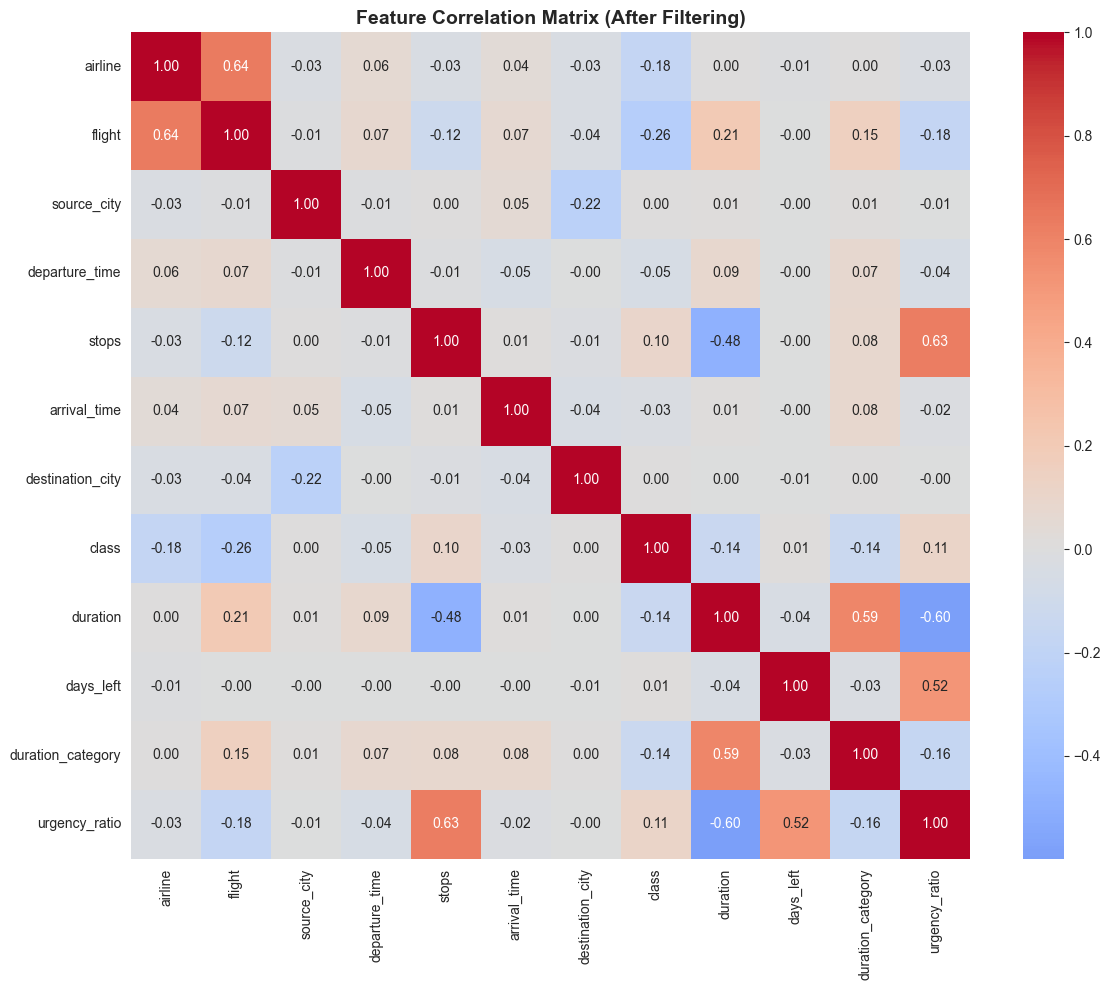

Correlation heatmap generated


In [ ]:
print('='*100)
print('STEP 4a: CORRELATION ANALYSIS - REMOVE HIGHLY CORRELATED FEATURES')
print('='*100)

print('\nChecking data types before correlation analysis...')
non_numeric_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()

if len(non_numeric_cols) > 0:
    print(f'\nERROR: Found {len(non_numeric_cols)} non-numeric columns:')
    for col in non_numeric_cols:
        print(f'   - {col}: {X_train_clean[col].dtype}')
        print(f'     Sample values: {X_train_clean[col].unique()[:3]}')
    print('\nCannot calculate correlations with non-numeric data!')
    print('Solution: Please run the encoding cell (Section 13) above to convert all categorical features to numeric.')
    raise ValueError('Non-numeric columns found. Please encode categorical features first.')
else:
    print('All columns are numeric - ready for correlation analysis!')

print('\nCalculating correlation matrix...')
corr_matrix = X_train_clean.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

correlation_threshold = 0.85
to_drop = [column for column in upper.columns if any(upper[column] > correlation_threshold)]

print(f'\nCorrelation threshold: {correlation_threshold}')
print(f'Features to drop due to high correlation: {len(to_drop)}')
if to_drop:
    print(f'\nFeatures being removed:')
    for feat in to_drop:
        corr_values = upper[feat][upper[feat] > correlation_threshold]
        for corr_feat, corr_val in corr_values.items():
            print(f'  - {feat} <-> {corr_feat}: {corr_val:.3f}')
    X_train_reduced = X_train_clean.drop(columns=to_drop)
    X_test_reduced = X_test_clean.drop(columns=to_drop)
else:
    print('No highly correlated features found')
    X_train_reduced = X_train_clean.copy()
    X_test_reduced = X_test_clean.copy()

print(f'\nShape after correlation filtering:')
print(f'  Train: {X_train_reduced.shape}')
print(f'  Test:  {X_test_reduced.shape}')

# Visualize correlation heatmap
print('\n' + '-'*100)
print('CORRELATION HEATMAP')
print('-'*100)
plt.figure(figsize=(12, 10))
sns.heatmap(X_train_reduced.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix (After Filtering)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Correlation heatmap generated')

### Step 4b: PCA Analysis (Optional Further Reduction)

STEP 4b: PCA ANALYSIS

Original number of features: 12
Components needed for 95% variance: 10


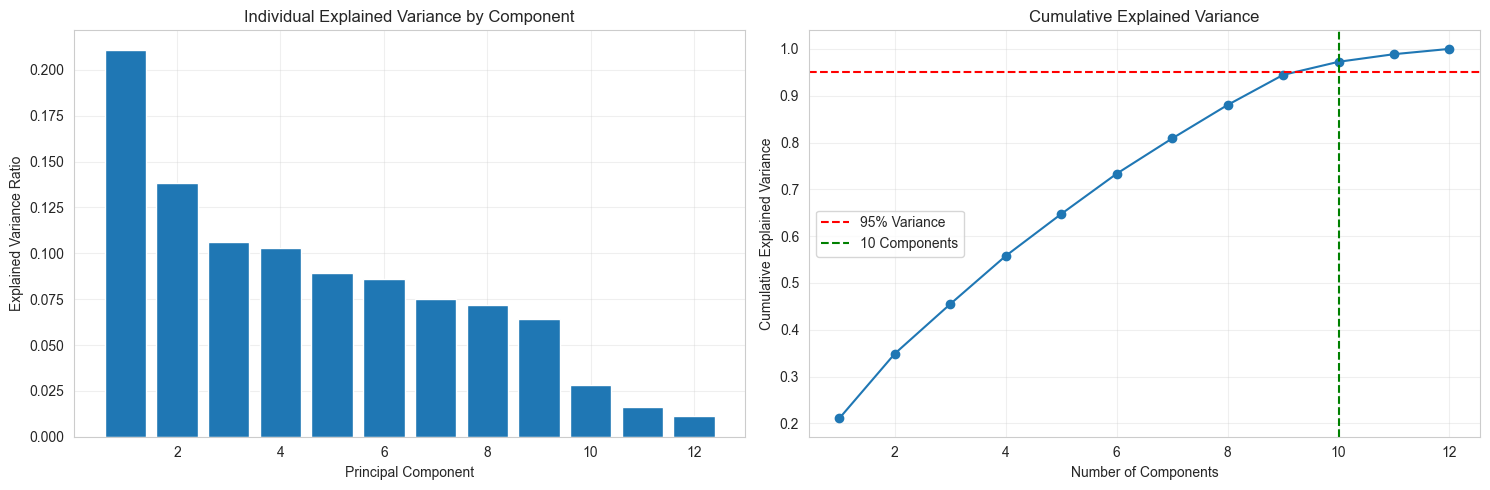


PCA analysis complete

Note: PCA transformation will be applied later if needed during model training
For now, we will continue with the correlation-filtered features.


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print('='*100)
print('STEP 4b: PCA ANALYSIS')
print('='*100)

scaler_pca = StandardScaler()
X_train_scaled_pca = scaler_pca.fit_transform(X_train_reduced)
X_test_scaled_pca = scaler_pca.transform(X_test_reduced)

pca_full = PCA()
pca_full.fit(X_train_scaled_pca)

cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1

print(f'\nOriginal number of features: {X_train_reduced.shape[1]}')
print(f'Components needed for 95% variance: {n_components_95}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.bar(range(1, len(pca_full.explained_variance_ratio_)+1), pca_full.explained_variance_ratio_)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Individual Explained Variance by Component')
ax1.grid(alpha=0.3)

ax2.plot(range(1, len(cumsum_variance)+1), cumsum_variance, marker='o')
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
ax2.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} Components')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nPCA analysis complete')
print(f'\nNote: PCA transformation will be applied later if needed during model training')
print(f'For now, we will continue with the correlation-filtered features.')

## Summary: Feature Engineering & Reduction Pipeline

### Processing Steps Completed:

**Step 1: Data Quality Check**
- Verified no missing values in train and test sets
- Checked and removed duplicate rows if present
- Ensured data integrity across both datasets

**Step 2: Categorical Encoding**
- Identified all categorical features (object and category dtypes)
- Applied Label Encoding to convert categorical to numeric
- Handled unseen categories in test set with -1 encoding
- Verified all features are numeric before proceeding

**Step 3: Feature Engineering**
- Created derived features:
  - `urgency_ratio`: days_left / (duration + 1)
  - `total_time`: duration + days_left
- Enhanced feature set with domain knowledge

**Step 4a: Correlation Analysis**
- Calculated correlation matrix for all numeric features
- Applied correlation threshold: 0.85
- Removed highly correlated features to reduce multicollinearity
- Generated correlation heatmap visualization

**Step 4b: PCA Analysis**
- Standardized features using StandardScaler
- Analyzed principal components for variance explanation
- Identified number of components needed for 95% variance
- Visualized explained variance distribution
- PCA transformation reserved for model training phase

### Key Outcomes:
- All features are numeric and ready for modeling
- Reduced feature dimensionality through correlation filtering
- Maintained data quality with no leakage between train/test
- Created engineered features for better predictive power
- Documented PCA requirements for future model optimization

